<div align="center">

# Production Quality Drift Detector
## Complete End-to-End Notebook

</div>



# PHASE 1 — DATA EXPLORATION & CLEANING



# 01 · Libraries & Configuration



In [1]:
import os
import glob
import re
from difflib import get_close_matches
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

sns.set_theme(style="whitegrid", context="notebook")

FILE_OVERRIDE = None


IQR_MULTIPLIER = 1.5
ROLLING_WINDOW = 25
Z_THRESHOLD = 3.0


CLEANED_OUTPUT = None

MANUAL_MAP = {}

print("✓ Configuration loaded")

✓ Configuration loaded



# 02 · Automatic File Discovery



In [2]:
def discover_csv():
    if FILE_OVERRIDE:
        override_path = Path(FILE_OVERRIDE)
        if not override_path.is_file():
            raise FileNotFoundError(
                f"FILE_OVERRIDE was set to '{FILE_OVERRIDE}', but the file was not found."
            )
        return str(override_path)

    search_dirs = [
        Path.cwd() / "Data",
        Path.cwd().parent / "Data",
    ]

    csv_files = []

    for directory in search_dirs:
        if directory.is_dir():
            csv_files.extend(directory.glob("*.csv"))

    csv_files = sorted(set(csv_files))

    if not csv_files:
        raise FileNotFoundError(
            "No CSV file was found in the Data folder."
        )

    if len(csv_files) == 1:
        return str(csv_files[0])

    keywords = (
        "raw",
        "dataset",
        "data",
        "production",
        "manufacturing",
        "quality",
    )

    preferred = [
        f for f in csv_files
        if any(k in f.name.lower() for k in keywords)
        and "cleaned" not in f.name.lower()
        and "processed" not in f.name.lower()
        and "output" not in f.name.lower()
    ]

    selected = preferred[0] if preferred else csv_files[0]

    print("CSV files detected:")
    for f in csv_files:
        marker = "  ← selected" if f == selected else ""
        print(f"  • {f}{marker}")

    return str(selected)


DATA_PATH = Path(discover_csv())
CLEANED_OUTPUT = DATA_PATH.parent / "Data_cleaned.csv"
df_raw = pd.read_csv(DATA_PATH)

print(f"\n✓ Loaded: {os.path.basename(DATA_PATH)}")
print(f"✓ Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]:,} columns")
display(df_raw.head())


✓ Loaded: Data_raw.csv
✓ Shape: 15,012 rows × 23 columns


,batch_id,timestamp,machine_id,product_line,temperature,pressure,cycle_time,vibration,quality_measurement,defect_rate,temperature_tolerance,pressure_tolerance,cycle_time_tolerance,vibration_tolerance,operator_shift,operator_id,raw_material_batch,ambient_temperature,energy_consumption,maintenance_days,production_speed,actual_status,final_outcome
0,7173,2026-03-16 17:00:00,M-06,Line-B,70.355,101.008,41.196,1.524,49.052,0.840,78.000,108.000,49.000,3.300,Shift-C,OP-002,RM-0094,24.730,89.800,81,99.610,Stable,Accepted
1,3533,2026-02-06 19:00:00,M-01,Line-D,68.145,97.744,43.248,1.889,49.463,0.938,78.000,108.000,49.000,3.300,Shift-C,OP-013,RM-0059,27.950,84.660,95,96.740,Stable,Accepted
2,8157,2026-03-26 23:00:00,M-01,Line-A,68.747,98.158,40.021,2.002,50.378,0.506,78.000,108.000,49.000,3.300,Shift-C,OP-021,RM-0053,22.380,80.300,10,97.580,Stable,Accepted
3,14405,2026-05-31 01:00:00,M-06,Line-A,74.347,104.482,43.383,3.423,46.077,3.767,78.000,108.000,49.000,3.300,Shift-A,OP-007,RM-0116,25.100,89.790,63,97.190,Critical,Rejected
4,380,2026-01-04 22:45:00,M-02,Line-D,70.760,101.084,42.198,1.843,50.846,0.866,78.000,108.000,49.000,3.300,Shift-C,OP-002,RM-0071,27.280,87.090,105,97.490,Stable,Accepted



# 03 · Universal Dataset Profile


In [3]:
numeric_cols_raw = df_raw.select_dtypes(include=np.number).columns.tolist()
categorical_cols_raw = df_raw.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

profile = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Numerical columns",
        "Categorical/text columns",
        "Missing cells",
        "Duplicate rows",
    ],
    "Value": [
        len(df_raw),
        df_raw.shape[1],
        len(numeric_cols_raw),
        len(categorical_cols_raw),
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()),
    ],
})

display(profile)

column_profile = pd.DataFrame({
    "Column": df_raw.columns,
    "Dtype": df_raw.dtypes.astype(str).values,
    "Missing": df_raw.isna().sum().values,
    "Missing %": (df_raw.isna().mean() * 100).round(3).values,
    "Unique": [df_raw[c].nunique(dropna=True) for c in df_raw.columns],
})

display(column_profile)

,Metric,Value
0,Rows,15012
1,Columns,23
2,Numerical columns,15
3,Categorical/text columns,8
4,Missing cells,239
5,Duplicate rows,12


,Column,Dtype,Missing,Missing %,Unique
0,batch_id,int64,0,0.000,15000
1,timestamp,object,0,0.000,14993
2,machine_id,object,0,0.000,7
3,product_line,object,0,0.000,6
4,temperature,float64,37,0.246,6841
5,pressure,float64,30,0.200,7104
6,cycle_time,float64,30,0.200,5678
7,vibration,float64,30,0.200,2371
8,quality_measurement,float64,37,0.246,6350
9,defect_rate,float64,0,0.000,4063



# 04 · Data Quality Audit




In [4]:
missing_report = (
    df_raw.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_pct=lambda x: x["missing_count"] / len(df_raw) * 100)
    .sort_values("missing_count", ascending=False)
)

print("Missing values:")
display(missing_report[missing_report["missing_count"] > 0])

print(f"Exact duplicate rows: {df_raw.duplicated().sum():,}")

constant_cols = [
    c for c in df_raw.columns
    if df_raw[c].nunique(dropna=False) <= 1
]

print("\nConstant columns:")
print(constant_cols if constant_cols else "None")

numeric_like = []

for col in categorical_cols_raw:
    converted = pd.to_numeric(df_raw[col], errors="coerce")
    rate = converted.notna().mean()

    if rate >= 0.90:
        numeric_like.append({
            "column": col,
            "numeric_conversion_rate_%": rate * 100
        })

print("\nText columns that appear mostly numeric:")
display(pd.DataFrame(numeric_like))

Missing values:


,missing_count,missing_pct
operator_id,45,0.300
quality_measurement,37,0.246
temperature,37,0.246
vibration,30,0.200
raw_material_batch,30,0.200
pressure,30,0.200
cycle_time,30,0.200


Exact duplicate rows: 12

Constant columns:
['temperature_tolerance', 'pressure_tolerance', 'cycle_time_tolerance', 'vibration_tolerance']

Text columns that appear mostly numeric:


""



# 05 · Universal Outlier Scan



,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_%
6,defect_rate,0.842,2.114,1.272,-1.066,4.023,1005,6.695
5,quality_measurement,47.880,50.234,2.354,44.350,53.764,598,3.983
2,pressure,99.372,102.328,2.956,94.939,106.762,128,0.853
12,energy_consumption,83.550,89.700,6.150,74.325,98.925,119,0.793
3,cycle_time,41.364,43.437,2.073,38.255,46.546,117,0.779
1,temperature,69.739,72.564,2.825,65.502,76.801,112,0.746
14,production_speed,97.198,101.060,3.862,91.404,106.854,110,0.733
4,vibration,1.891,2.670,0.779,0.723,3.838,41,0.273
0,batch_id,"3,750.750","11,249.250","7,498.500","-7,497.000","22,497.000",0,0.000
7,temperature_tolerance,78.000,78.000,0.000,78.000,78.000,0,0.000


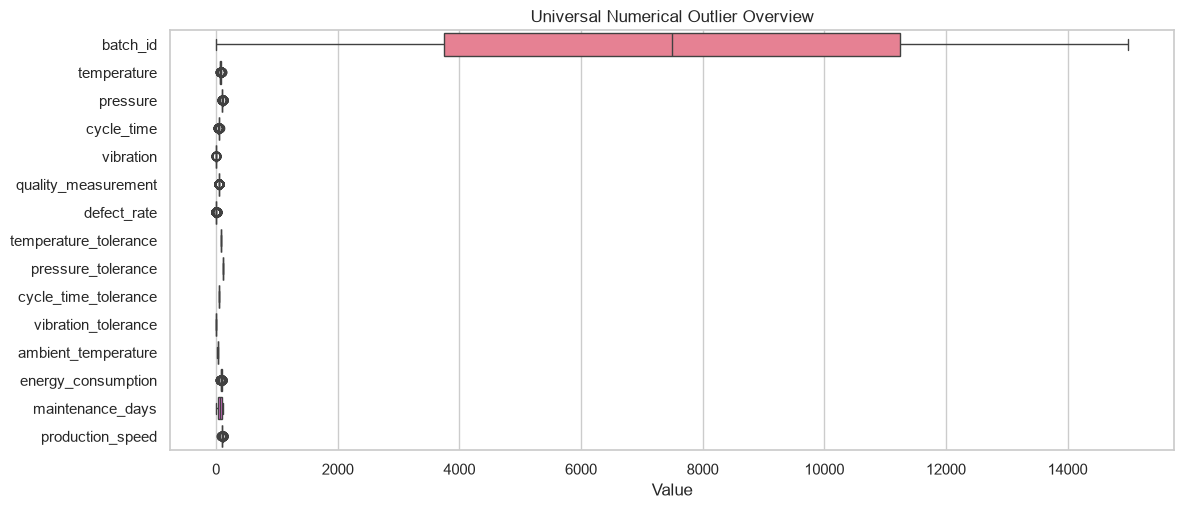

In [5]:
outlier_rows = []

for col in numeric_cols_raw:
    series = df_raw[col].dropna()

    if series.empty:
        continue

    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - IQR_MULTIPLIER * iqr
    upper = q3 + IQR_MULTIPLIER * iqr

    mask = (df_raw[col] < lower) | (df_raw[col] > upper)

    outlier_rows.append({
        "column": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower,
        "upper_bound": upper,
        "outlier_count": int(mask.sum()),
        "outlier_%": mask.mean() * 100,
    })

outlier_report = pd.DataFrame(outlier_rows).sort_values(
    "outlier_count", ascending=False
)

display(outlier_report.round(3))

if numeric_cols_raw:
    plt.figure(figsize=(12, max(5, len(numeric_cols_raw) * 0.35)))
    sns.boxplot(data=df_raw[numeric_cols_raw], orient="h")
    plt.title("Universal Numerical Outlier Overview")
    plt.xlabel("Value")
    plt.tight_layout()
    plt.show()


# 06 · Automatic Manufacturing Concept Detection



In [6]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    name = re.sub(r"_+", "_", name).strip("_")
    return name


ALIASES = {
    "batch_id": [
        "batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"
    ],
    "timestamp": [
        "timestamp", "datetime", "date_time", "date", "recorded_at",
        "recorded_time", "created_at"
    ],
    "machine_id": [
        "machine_id", "machine", "machine_no", "machine_number", "equipment_id"
    ],
    "product_line": [
        "product_line", "production_line", "line", "line_id", "product"
    ],
    "temperature": [
        "temperature", "temp", "temp_c", "temperature_c", "temperature_celsius",
        "machine_temperature"
    ],
    "pressure": [
        "pressure", "press", "pressure_psi", "pressure_bar", "machine_pressure"
    ],
    "cycle_time": [
        "cycle_time", "cycle_duration", "cycle_time_sec", "cycle_duration_sec",
        "duration", "processing_time", "cycle_seconds"
    ],
    "vibration": [
        "vibration", "vibration_level", "vibration_mm_s", "vibration_rms",
        "machine_vibration"
    ],
    "quality_measurement": [
        "quality_measurement", "quality_score", "quality", "quality_index"
    ],
    "defect_rate": [
        "defect_rate", "defect_percentage", "defect_pct", "defect_ratio",
        "defects_rate"
    ],
    "actual_status": [
        "actual_status", "status", "process_status", "quality_status", "condition"
    ],
    "final_outcome": [
        "final_outcome", "outcome", "result", "final_result", "decision"
    ],
    "temperature_tolerance": [
        "temperature_tolerance", "temp_tolerance", "temperature_limit",
        "temp_limit", "temperature_upper_limit"
    ],
    "pressure_tolerance": [
        "pressure_tolerance", "pressure_limit", "pressure_upper_limit"
    ],
    "cycle_time_tolerance": [
        "cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit",
        "cycle_duration_limit"
    ],
    "vibration_tolerance": [
        "vibration_tolerance", "vibration_limit", "vibration_upper_limit"
    ],
}


normalized_columns = {
    normalize_name(col): col
    for col in df_raw.columns
}


def detect_column(concept):
    if concept in MANUAL_MAP:
        requested = MANUAL_MAP[concept]
        if requested not in df_raw.columns:
            raise ValueError(
                f"Manual mapping '{concept}: {requested}' does not exist in the dataset."
            )
        return requested

    aliases = [normalize_name(x) for x in ALIASES.get(concept, [])]

    for alias in aliases:
        if alias in normalized_columns:
            return normalized_columns[alias]

    normalized_names = list(normalized_columns.keys())

    for alias in aliases:
        matches = get_close_matches(alias, normalized_names, n=1, cutoff=0.88)
        if matches:
            return normalized_columns[matches[0]]

    keywords = {
        "temperature": ["temperature", "temp"],
        "pressure": ["pressure", "press"],
        "cycle_time": ["cycle", "duration"],
        "vibration": ["vibration"],
        "quality_measurement": ["quality"],
        "defect_rate": ["defect"],
        "batch_id": ["batch", "lot"],
        "timestamp": ["timestamp", "datetime", "recorded", "date_time"],
        "machine_id": ["machine", "equipment"],
        "product_line": ["product_line", "production_line", "line"],
        "actual_status": ["status", "condition"],
        "final_outcome": ["outcome", "result", "decision"],
    }

    for col in df_raw.columns:
        normalized = normalize_name(col)
        if any(k in normalized for k in keywords.get(concept, [])):
            return col

    return None


COLUMN_MAP = {
    concept: detect_column(concept)
    for concept in ALIASES
}

mapping_table = pd.DataFrame([
    {
        "Concept": concept,
        "Detected column": col if col else "NOT FOUND",
        "Source": (
            "Manual override" if concept in MANUAL_MAP
            else "Automatic detection" if col
            else "Unavailable"
        )
    }
    for concept, col in COLUMN_MAP.items()
])

display(mapping_table)

,Concept,Detected column,Source
0,batch_id,batch_id,Automatic detection
1,timestamp,timestamp,Automatic detection
2,machine_id,machine_id,Automatic detection
3,product_line,product_line,Automatic detection
4,temperature,temperature,Automatic detection
5,pressure,pressure,Automatic detection
6,cycle_time,cycle_time,Automatic detection
7,vibration,vibration,Automatic detection
8,quality_measurement,quality_measurement,Automatic detection
9,defect_rate,defect_rate,Automatic detection



# 07 · PS Variable Availability



In [7]:
PROCESS_CONCEPTS = ["temperature", "pressure", "cycle_time", "vibration"]
QUALITY_CONCEPTS = ["quality_measurement", "defect_rate"]

available_process = {
    concept: COLUMN_MAP[concept]
    for concept in PROCESS_CONCEPTS
    if COLUMN_MAP[concept] is not None
}

available_quality = {
    concept: COLUMN_MAP[concept]
    for concept in QUALITY_CONCEPTS
    if COLUMN_MAP[concept] is not None
}

print("CORE PROCESS VARIABLES")
for concept in PROCESS_CONCEPTS:
    status = available_process.get(concept, "NOT FOUND")
    print(f"  {'✓' if concept in available_process else '–'} {concept:24s} → {status}")

print("\nQUALITY VARIABLES")
for concept in QUALITY_CONCEPTS:
    status = available_quality.get(concept, "NOT FOUND")
    print(f"  {'✓' if concept in available_quality else '–'} {concept:24s} → {status}")

missing_process = [
    concept for concept in PROCESS_CONCEPTS
    if concept not in available_process
]

if missing_process:
    print("\nNote: missing PS variables will simply be skipped.")

CORE PROCESS VARIABLES
  ✓ temperature              → temperature
  ✓ pressure                 → pressure
  ✓ cycle_time               → cycle_time
  ✓ vibration                → vibration

QUALITY VARIABLES
  ✓ quality_measurement      → quality_measurement
  ✓ defect_rate              → defect_rate



# 08 · Raw Distributions


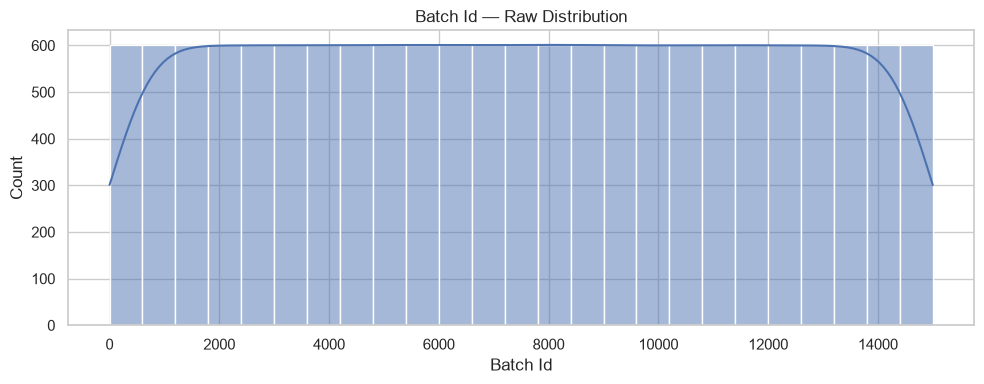

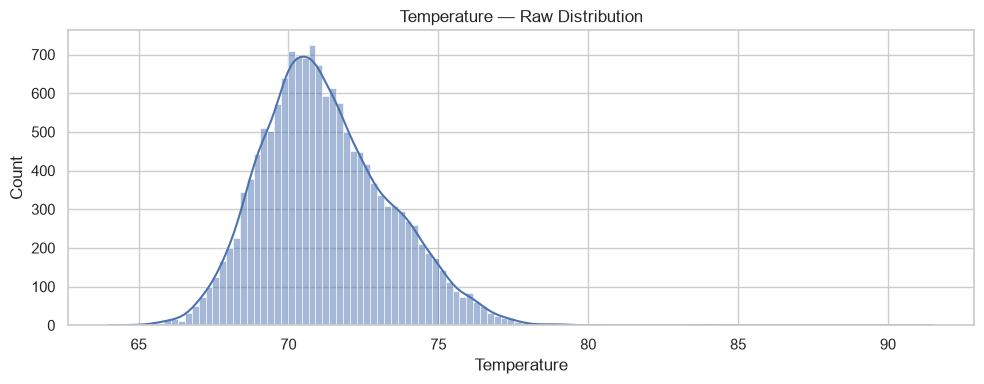

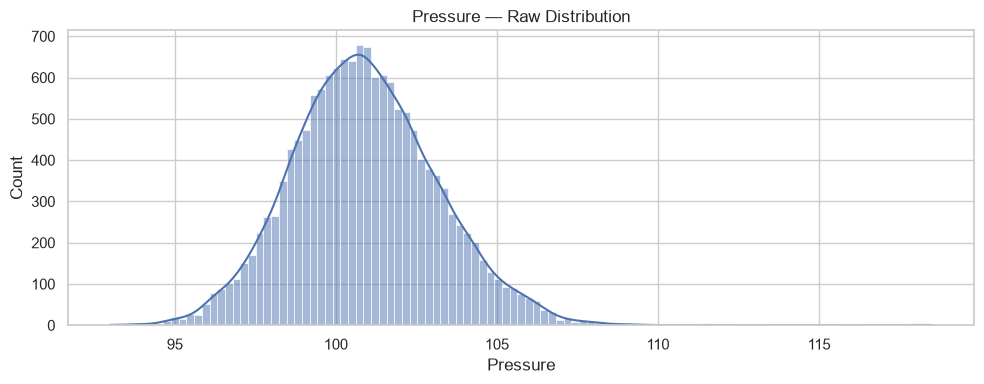

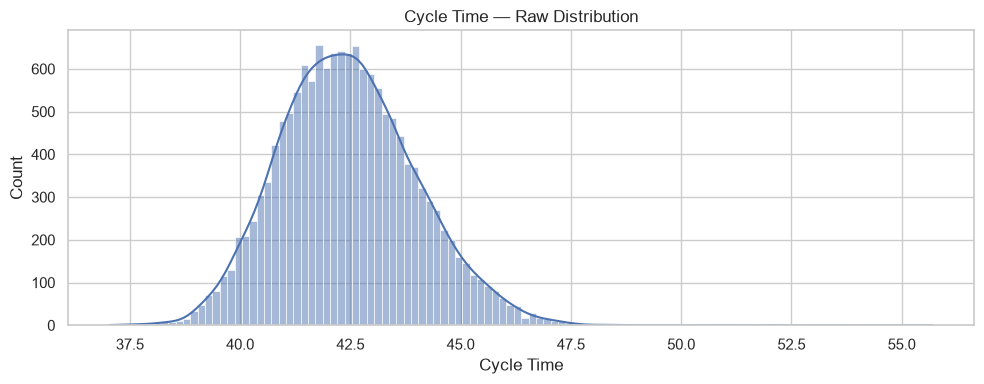

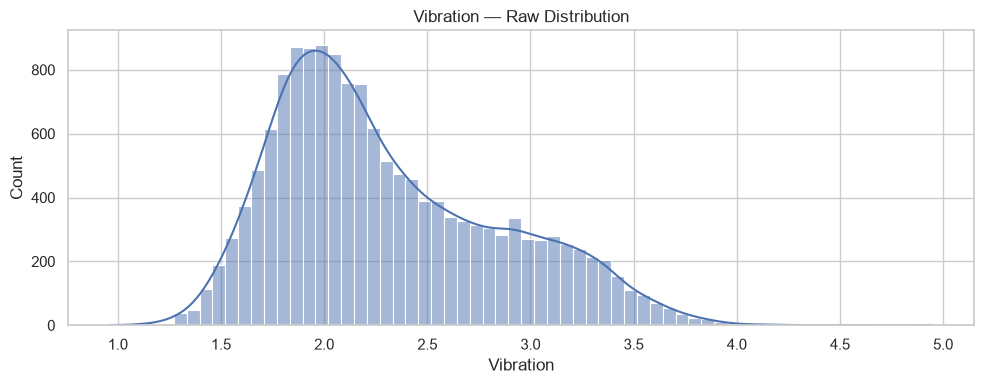

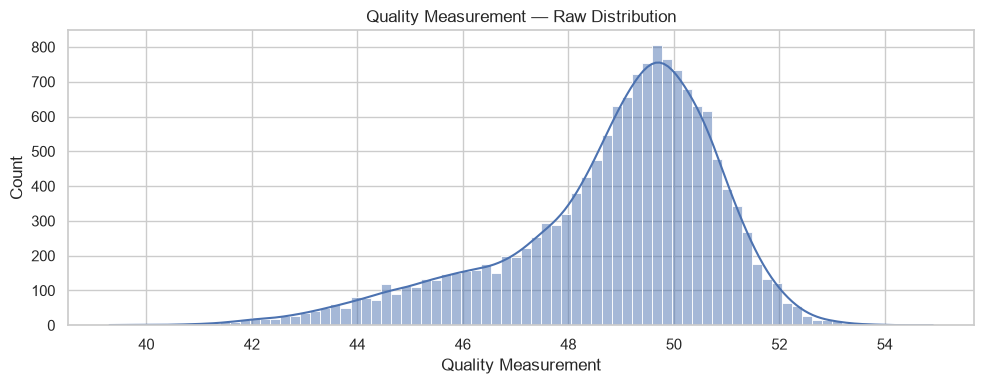

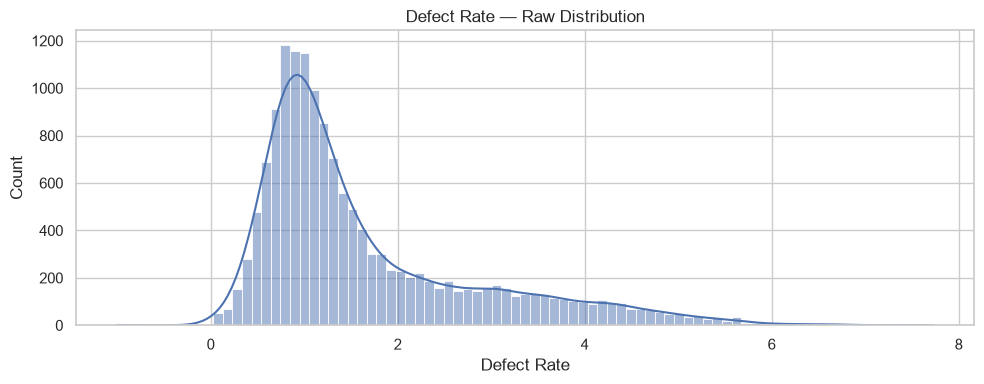

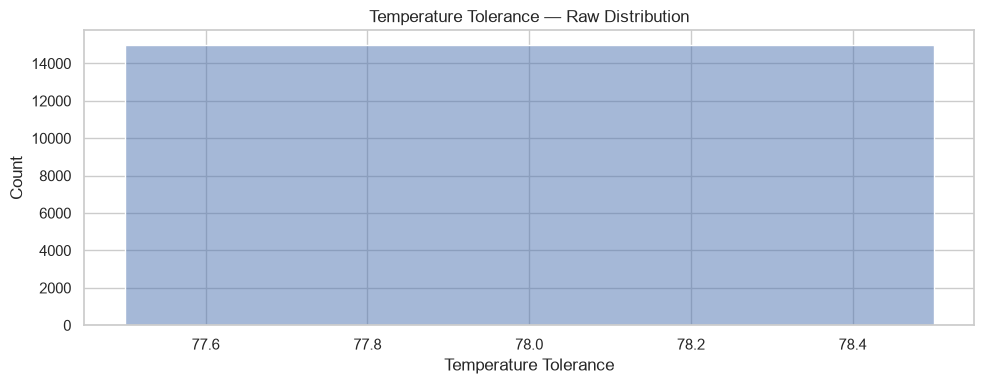

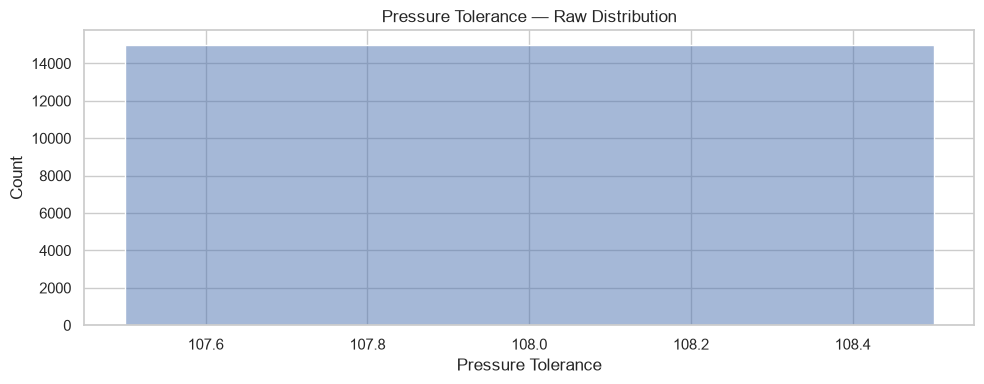

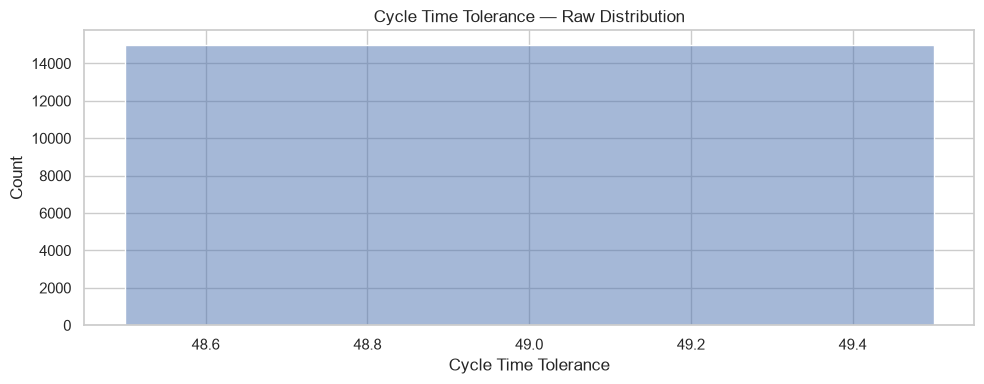

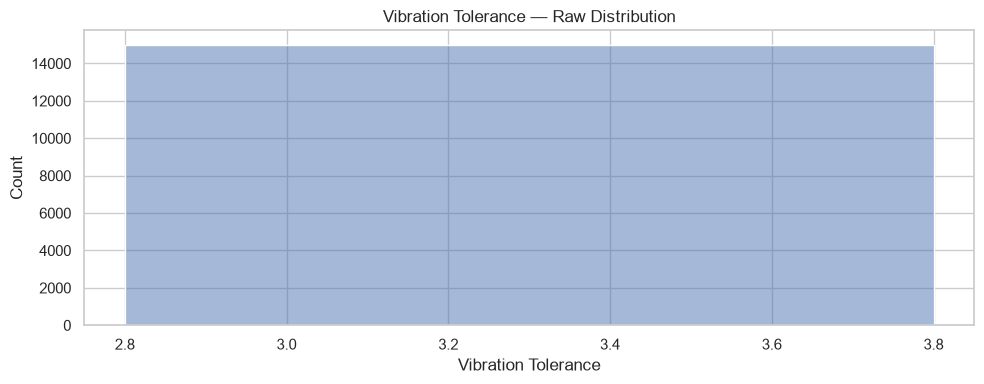

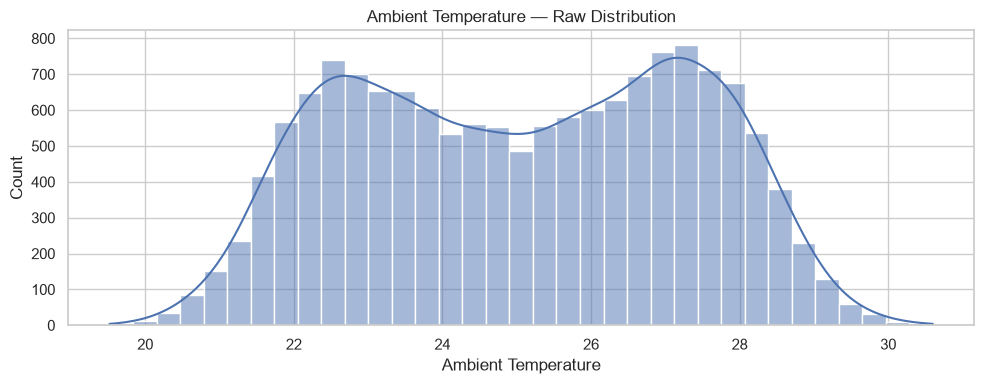

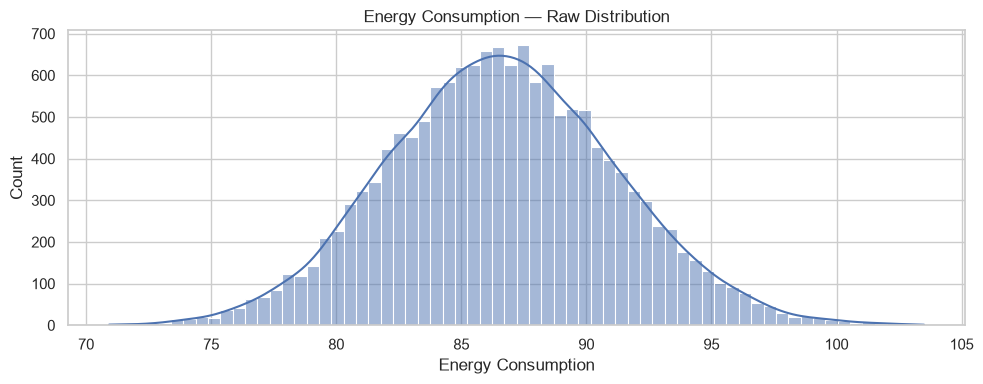

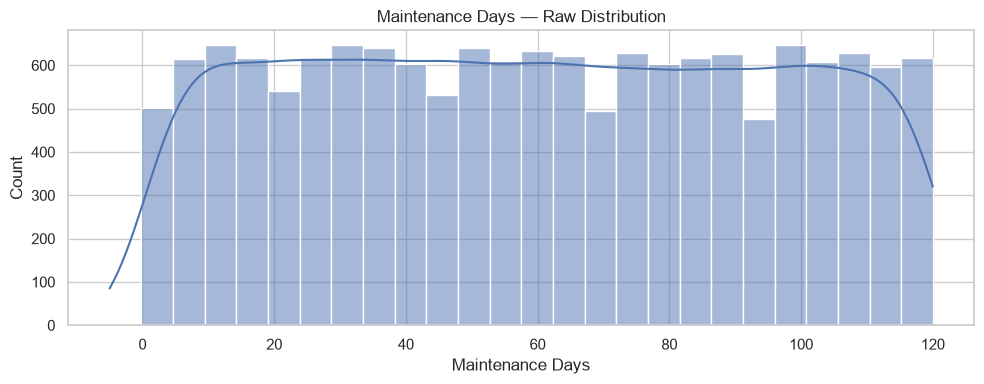

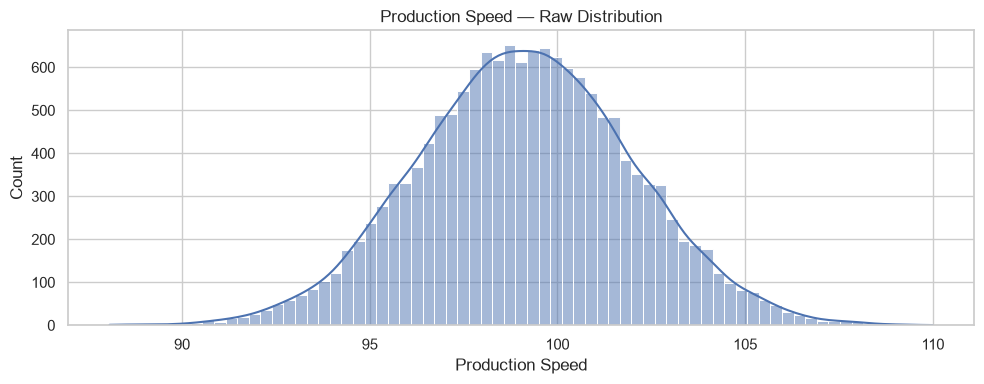

In [8]:
for col in numeric_cols_raw:
    plt.figure(figsize=(10, 4))
    sns.histplot(df_raw[col].dropna(), kde=True)
    plt.title(f"{col.replace('_', ' ').title()} — Raw Distribution")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


# 09 · Categorical Exploration


### timestamp — 14,993 unique values


,count
timestamp,
not_available,8
2026-01-02 01:00:00,2
2026-03-03 21:45:00,2
2026-02-22 06:15:00,2
2026-03-28 14:15:00,2
2026-06-03 00:15:00,2
2026-03-18 10:00:00,2
2026-03-31 09:15:00,2
2026-02-24 09:15:00,2


### machine_id — 7 unique values


,count
machine_id,
M-04,2553
M-01,2541
M-02,2530
M-03,2498
M-06,2446
M-05,2440
m-03,4


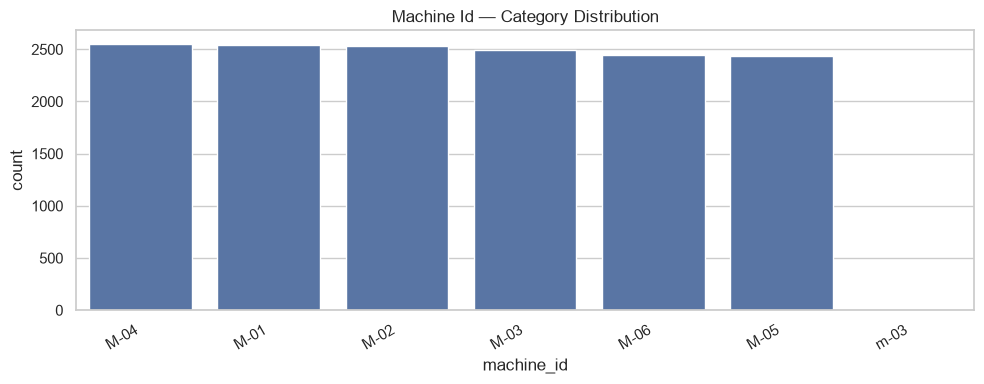

### product_line — 6 unique values


,count
product_line,
Line-B,4088
Line-A,4025
Line-C,3844
Line-D,3039
LINE-B,8
line-a,8


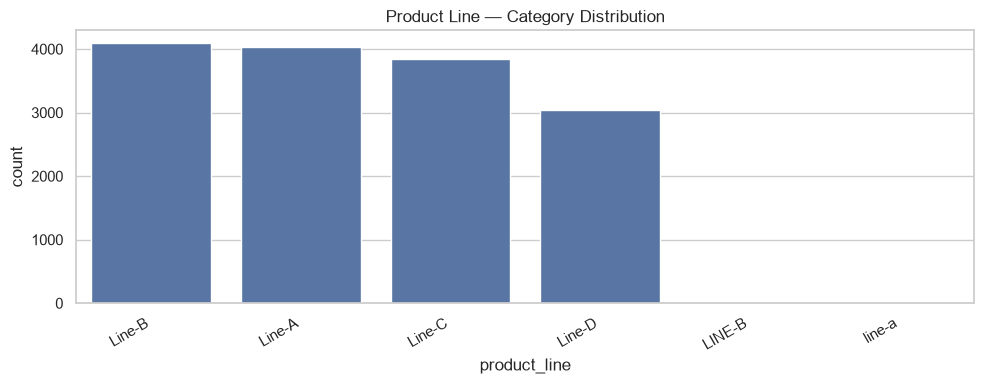

### operator_shift — 4 unique values


,count
operator_shift,
Shift-A,5019
Shift-C,4995
Shift-B,4994
shift-a,4


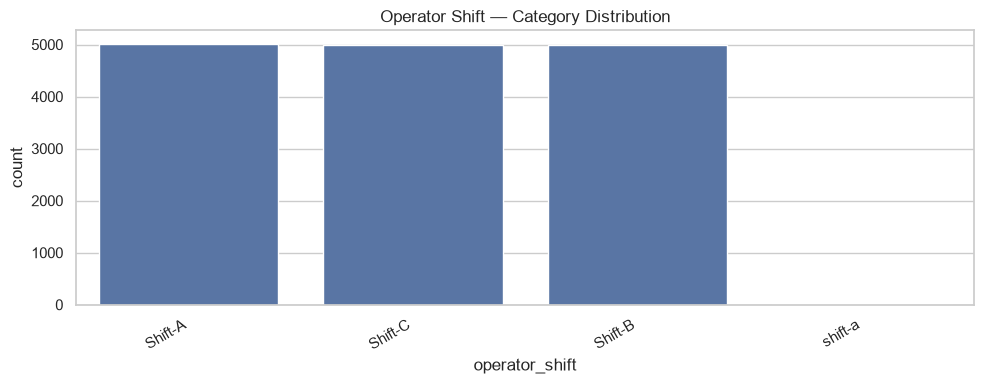

### operator_id — 30 unique values


,count
operator_id,
OP-023,562
OP-014,537
OP-002,534
OP-025,526
OP-024,525
OP-026,520
OP-019,517
OP-003,512
OP-004,512


### raw_material_batch — 150 unique values


,count
raw_material_batch,
RM-0025,129
RM-0144,128
RM-0040,126
RM-0146,124
RM-0115,123
RM-0122,123
RM-0113,117
RM-0019,116
RM-0116,115


### actual_status — 3 unique values


,count
actual_status,
Stable,9792
Warning,3519
Critical,1701


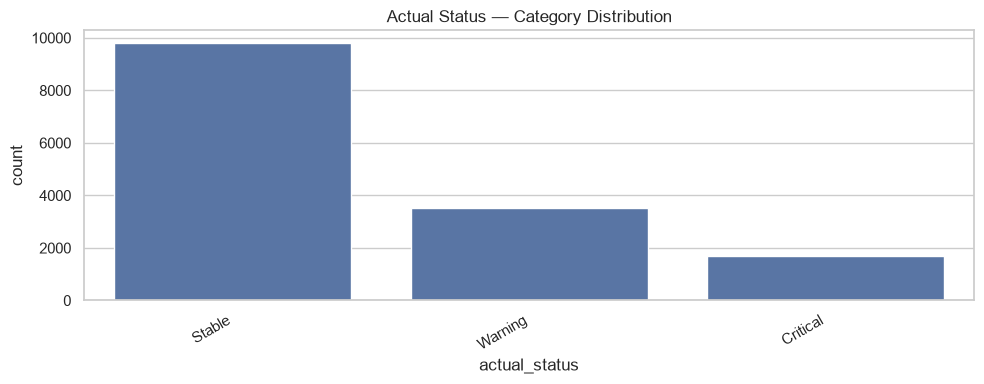

### final_outcome — 3 unique values


,count
final_outcome,
Accepted,12265
Rejected,1701
Rework,1046


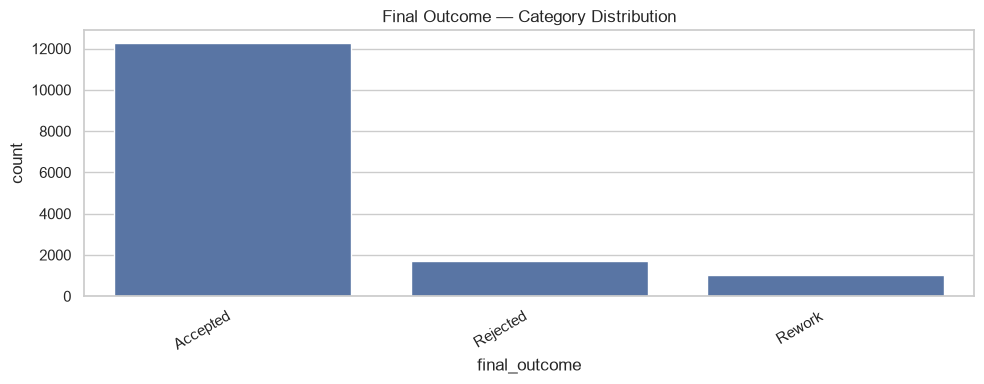

In [9]:
for col in categorical_cols_raw:
    unique_count = df_raw[col].nunique(dropna=True)

    print(f"### {col} — {unique_count:,} unique values")
    display(df_raw[col].value_counts(dropna=False).head(15).to_frame("count"))

    if 1 < unique_count <= 20:
        plt.figure(figsize=(10, 4))
        sns.countplot(
            data=df_raw,
            x=col,
            order=df_raw[col].value_counts().head(20).index
        )
        plt.title(f"{col.replace('_', ' ').title()} — Category Distribution")
        plt.xticks(rotation=30, ha="right")
        plt.tight_layout()
        plt.show()


# 10 · Conservative Data Cleaning



In [10]:
df = df_raw.copy()
cleaning_log = []

converted_columns = []

for col in df.select_dtypes(include=["object", "string"]).columns:
    converted = pd.to_numeric(df[col], errors="coerce")
    rate = converted.notna().mean()

    if rate >= 0.95:
        df[col] = converted
        converted_columns.append(col)

cleaning_log.append({
    "action": "Numeric-like text converted",
    "count": len(converted_columns),
    "details": ", ".join(converted_columns) if converted_columns else "None"
})

timestamp_col = COLUMN_MAP.get("timestamp")
rows_before = len(df)

if timestamp_col:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")

    invalid_timestamp_count = int(df[timestamp_col].isna().sum())
    df = df.dropna(subset=[timestamp_col]).copy()

    cleaning_log.append({
        "action": "Invalid/missing timestamps removed",
        "count": invalid_timestamp_count,
        "details": timestamp_col
    })
else:
    cleaning_log.append({
        "action": "Timestamp cleaning",
        "count": 0,
        "details": "No timestamp column detected"
    })

duplicate_count = int(df.duplicated().sum())
df = df.drop_duplicates().copy()

cleaning_log.append({
    "action": "Exact duplicate rows removed",
    "count": duplicate_count,
    "details": "Exact row duplicates"
})

text_cols = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

for col in text_cols:
    df[col] = df[col].astype("string").str.strip()

machine_col = COLUMN_MAP.get("machine_id")
line_col = COLUMN_MAP.get("product_line")

if machine_col:
    df[machine_col] = df[machine_col].str.upper()

if line_col:
    df[line_col] = df[line_col].str.title()

defect_col = COLUMN_MAP.get("defect_rate")

if defect_col and pd.api.types.is_numeric_dtype(df[defect_col]):
    invalid = df[defect_col] < 0
    count = int(invalid.sum())
    df.loc[invalid, defect_col] = np.nan

    cleaning_log.append({
        "action": "Negative defect rates converted to missing",
        "count": count,
        "details": defect_col
    })

maintenance_col = next(
    (
        col for col in df.columns
        if "maintenance" in normalize_name(col)
        and "day" in normalize_name(col)
    ),
    None
)

if maintenance_col and pd.api.types.is_numeric_dtype(df[maintenance_col]):
    invalid = df[maintenance_col] < 0
    count = int(invalid.sum())
    df.loc[invalid, maintenance_col] = np.nan

    cleaning_log.append({
        "action": "Negative maintenance days converted to missing",
        "count": count,
        "details": maintenance_col
    })

numeric_cols_clean = df.select_dtypes(include=np.number).columns.tolist()

numeric_imputed = []

for col in numeric_cols_clean:
    count = int(df[col].isna().sum())

    if count:
        df[col] = df[col].fillna(df[col].median())
        numeric_imputed.append((col, count))

cleaning_log.append({
    "action": "Numerical missing values median-imputed",
    "count": sum(x[1] for x in numeric_imputed),
    "details": ", ".join(f"{c} ({n})" for c, n in numeric_imputed) or "None"
})

protected_cols = {
    c for c in [
        COLUMN_MAP.get("actual_status"),
        COLUMN_MAP.get("final_outcome")
    ] if c is not None
}

categorical_cols_clean = df.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

categorical_imputed = []

for col in categorical_cols_clean:
    if col in protected_cols:
        continue

    count = int(df[col].isna().sum())

    if count:
        mode = df[col].mode(dropna=True)
        if len(mode):
            df[col] = df[col].fillna(mode.iloc[0])
            categorical_imputed.append((col, count))

cleaning_log.append({
    "action": "Categorical missing values mode-imputed",
    "count": sum(x[1] for x in categorical_imputed),
    "details": ", ".join(f"{c} ({n})" for c, n in categorical_imputed) or "None"
})

if timestamp_col:
    sort_cols = [timestamp_col]
    batch_col = COLUMN_MAP.get("batch_id")

    if batch_col and batch_col in df.columns:
        sort_cols.append(batch_col)

    df = df.sort_values(sort_cols).reset_index(drop=True)

print(f"✓ Cleaning complete: {len(df):,} rows × {df.shape[1]:,} columns")

cleaning_log_df = pd.DataFrame(cleaning_log)
display(cleaning_log_df)

✓ Cleaning complete: 14,992 rows × 23 columns


,action,count,details
0,Numeric-like text converted,0,None
1,Invalid/missing timestamps removed,8,timestamp
2,Exact duplicate rows removed,12,Exact row duplicates
3,Negative defect rates converted to missing,5,defect_rate
4,Negative maintenance days converted to missing,4,maintenance_days
5,Numerical missing values median-imputed,173,"temperature (37), pressure (30), cycle_time (3..."
6,Categorical missing values mode-imputed,75,"operator_id (45), raw_material_batch (30)"



# 11 · Cleaning Validation



In [11]:
validation = pd.DataFrame({
    "Metric": [
        "Rows",
        "Columns",
        "Missing cells",
        "Duplicate rows",
    ],
    "Raw": [
        len(df_raw),
        df_raw.shape[1],
        int(df_raw.isna().sum().sum()),
        int(df_raw.duplicated().sum()),
    ],
    "Cleaned": [
        len(df),
        df.shape[1],
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
    ]
})

validation["Change"] = validation["Cleaned"] - validation["Raw"]

display(validation)

remaining_missing = (
    df.isna()
      .sum()
      .to_frame("remaining_missing")
      .query("remaining_missing > 0")
)

print("Remaining missing values:")
display(remaining_missing if not remaining_missing.empty else pd.DataFrame(
    {"result": ["✓ No missing values remain in the cleaned dataset"]}
))

,Metric,Raw,Cleaned,Change
0,Rows,15012,14992,-20
1,Columns,23,23,0
2,Missing cells,239,0,-239
3,Duplicate rows,12,0,-12


Remaining missing values:


,result
0,✓ No missing values remain in the cleaned dataset



# 12 · Clean Numerical Statistics



In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

if numeric_cols:
    stats = df[numeric_cols].describe().T
    stats["IQR"] = stats["75%"] - stats["25%"]
    stats["CV_%"] = (
        stats["std"] /
        stats["mean"].replace(0, np.nan) * 100
    )

    display(stats.round(3))
else:
    print("No numerical columns available.")

,count,mean,std,min,25%,50%,75%,max,IQR,CV_%
batch_id,"14,992.000","7,498.913","4,330.504",1.000,"3,748.750","7,498.500","11,249.250","15,000.000","7,500.500",57.748
temperature,"14,992.000",71.227,2.136,64.030,69.743,70.983,72.558,91.499,2.816,2.999
pressure,"14,992.000",100.901,2.258,92.974,99.375,100.804,102.322,118.536,2.947,2.238
cycle_time,"14,992.000",42.447,1.544,37.039,41.368,42.372,43.434,55.707,2.066,3.638
vibration,"14,992.000",2.304,0.544,0.960,1.891,2.171,2.668,4.950,0.777,23.615
quality_measurement,"14,992.000",48.837,2.039,39.302,47.886,49.291,50.231,54.911,2.345,4.174
defect_rate,"14,992.000",1.656,1.196,0.050,0.842,1.200,2.114,7.727,1.272,72.224
temperature_tolerance,"14,992.000",78.000,0.000,78.000,78.000,78.000,78.000,78.000,0.000,0.000
pressure_tolerance,"14,992.000",108.000,0.000,108.000,108.000,108.000,108.000,108.000,0.000,0.000
cycle_time_tolerance,"14,992.000",49.000,0.000,49.000,49.000,49.000,49.000,49.000,0.000,0.000



# 13 · Production Quality Status



,status,batch_count,percentage
0,Stable,9780,65.230
1,Warning,3514,23.440
2,Critical,1698,11.330


Mean process measurements by status:


,temperature,pressure,cycle_time,vibration
actual_status,,,,
Critical,74.767,103.489,44.476,3.296
Stable,70.203,100.121,41.901,2.008
Warning,72.364,101.822,42.986,2.647


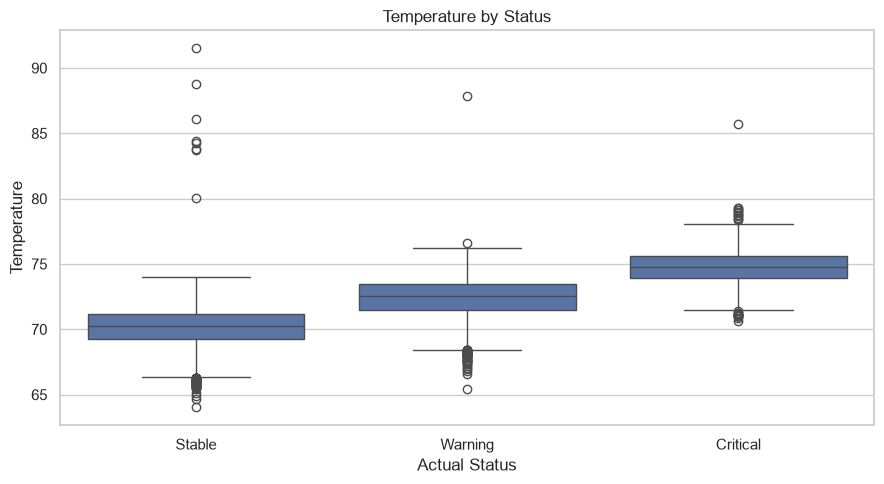

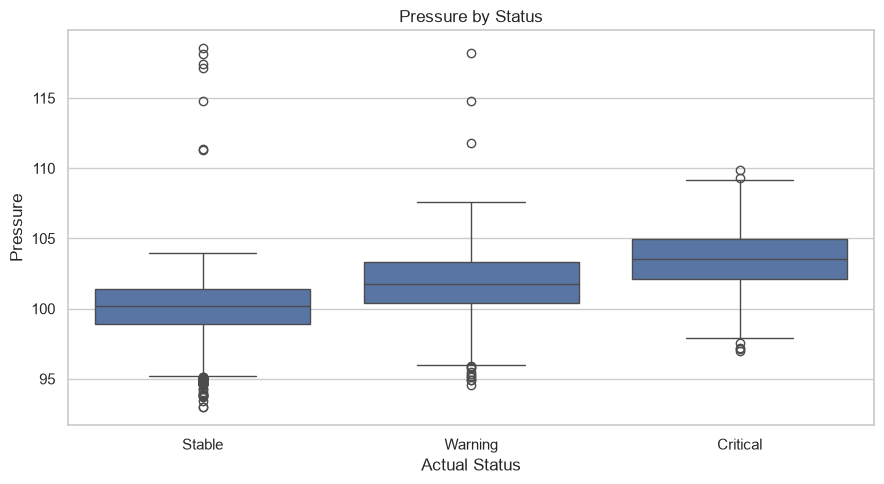

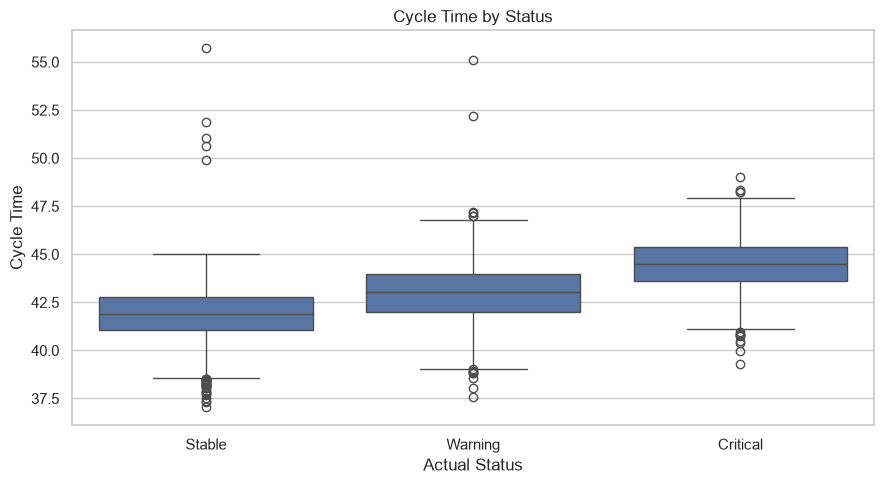

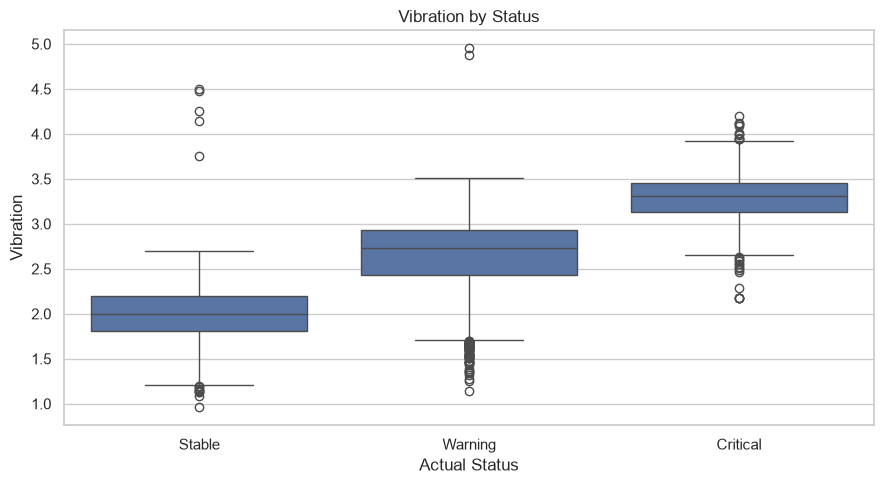

In [13]:
status_col = COLUMN_MAP.get("actual_status")

if status_col:
    status_counts = (
        df[status_col]
        .value_counts(dropna=False)
        .rename_axis("status")
        .reset_index(name="batch_count")
    )

    status_counts["percentage"] = (
        status_counts["batch_count"] / len(df) * 100
    )

    display(status_counts.round(2))

    if available_process:
        process_cols = list(available_process.values())

        status_means = df.groupby(status_col)[process_cols].mean()
        print("Mean process measurements by status:")
        display(status_means.round(3))

        for concept, col in available_process.items():
            if pd.api.types.is_numeric_dtype(df[col]) and df[col].nunique() > 1:
                plt.figure(figsize=(9, 5))
                sns.boxplot(data=df, x=status_col, y=col)
                plt.title(f"{concept.replace('_', ' ').title()} by Status")
                plt.xlabel(status_col.replace("_", " ").title())
                plt.ylabel(col.replace("_", " ").title())
                plt.tight_layout()
                plt.show()
else:
    print("No status column detected — status analysis skipped.")


# 14 · Correlation Analysis



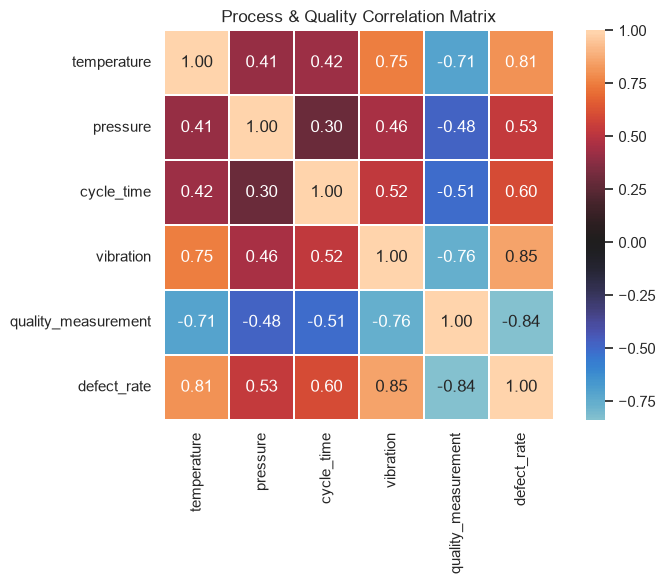

In [14]:
if len(numeric_cols) >= 2:
    ps_numeric = list(dict.fromkeys(
        list(available_process.values()) +
        list(available_quality.values())
    ))

    heatmap_cols = ps_numeric if len(ps_numeric) >= 2 else numeric_cols[:20]

    plt.figure(figsize=(max(8, len(heatmap_cols) * 0.6),
                        max(6, len(heatmap_cols) * 0.5)))

    sns.heatmap(
        df[heatmap_cols].corr(),
        annot=len(heatmap_cols) <= 12,
        fmt=".2f",
        center=0,
        square=True,
        linewidths=0.3
    )

    plt.title("Process & Quality Correlation Matrix")
    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical variables for correlation analysis.")


# 15 · Tolerance Proximity



In [15]:
TOLERANCE_CONCEPTS = {
    "temperature": "temperature_tolerance",
    "pressure": "pressure_tolerance",
    "cycle_time": "cycle_time_tolerance",
    "vibration": "vibration_tolerance",
}

tolerance_results = []

for concept, tolerance_concept in TOLERANCE_CONCEPTS.items():
    value_col = COLUMN_MAP.get(concept)
    tolerance_col = COLUMN_MAP.get(tolerance_concept)

    if not value_col or not tolerance_col:
        continue

    if not (
        pd.api.types.is_numeric_dtype(df[value_col])
        and pd.api.types.is_numeric_dtype(df[tolerance_col])
    ):
        continue

    distance_col = f"{concept}_tolerance_distance"
    utilization_col = f"{concept}_limit_utilization_pct"

    df[distance_col] = df[tolerance_col] - df[value_col]
    df[utilization_col] = (
        df[value_col] /
        df[tolerance_col].replace(0, np.nan) * 100
    )

    tolerance_results.append({
        "variable": concept,
        "measurement_column": value_col,
        "tolerance_column": tolerance_col,
        "mean_distance": df[distance_col].mean(),
        "minimum_distance": df[distance_col].min(),
        "maximum_utilization_%": df[utilization_col].max(),
        "at_or_above_limit": int((df[distance_col] <= 0).sum()),
    })

if tolerance_results:
    tolerance_report = pd.DataFrame(tolerance_results)
    display(tolerance_report.round(3))
else:
    print("No complete process/tolerance pairs detected.")

,variable,measurement_column,tolerance_column,mean_distance,minimum_distance,maximum_utilization_%,at_or_above_limit
0,temperature,temperature,temperature_tolerance,6.773,-13.499,117.306,23
1,pressure,pressure,pressure_tolerance,7.099,-10.536,109.755,31
2,cycle_time,cycle_time,cycle_time_tolerance,6.553,-6.707,113.687,8
3,vibration,vibration,vibration_tolerance,0.996,-1.650,150.005,886



# 16 · Production Timeline



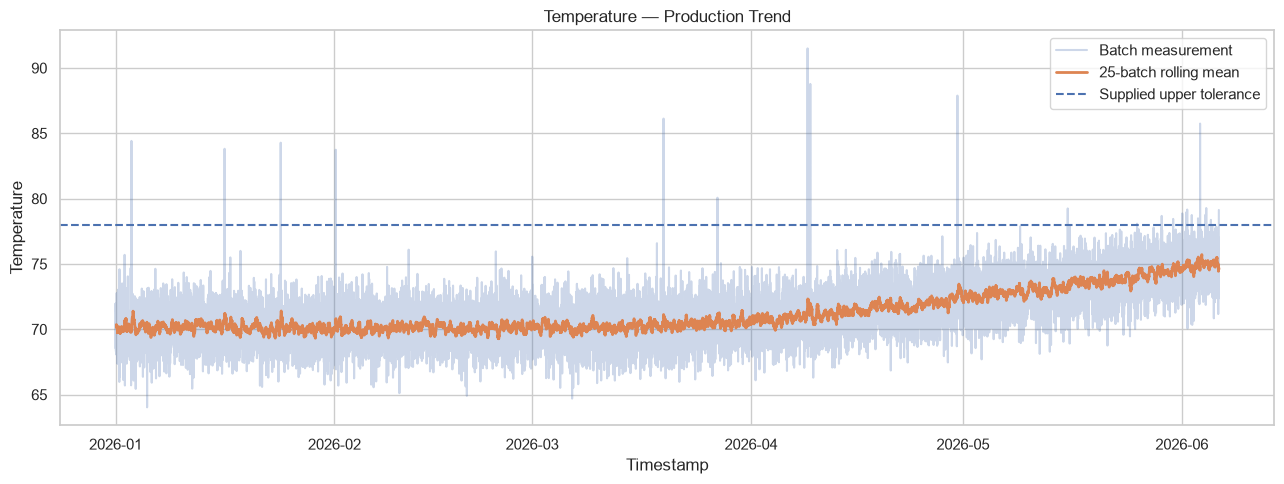

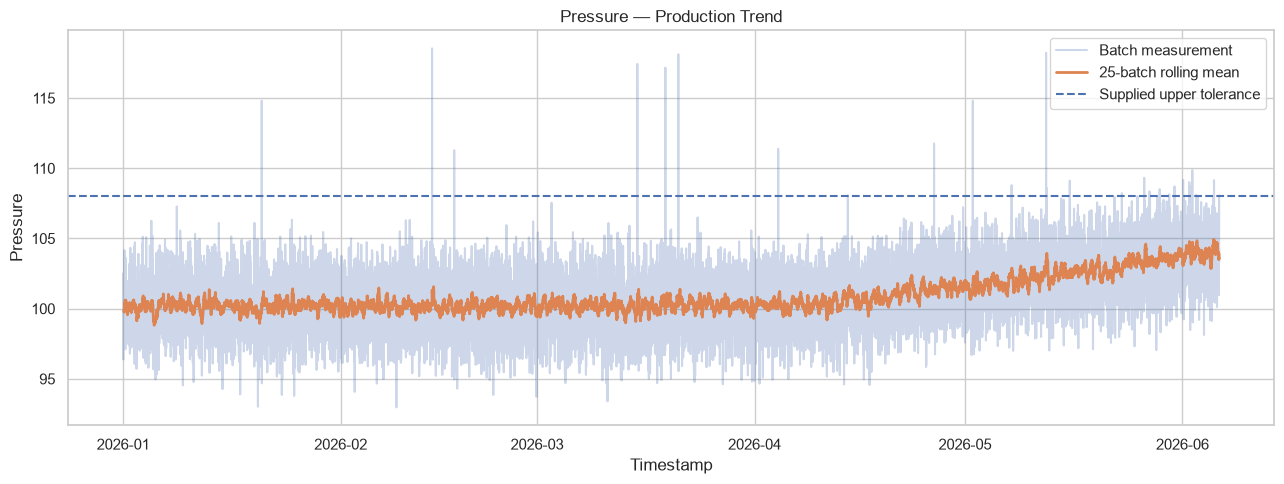

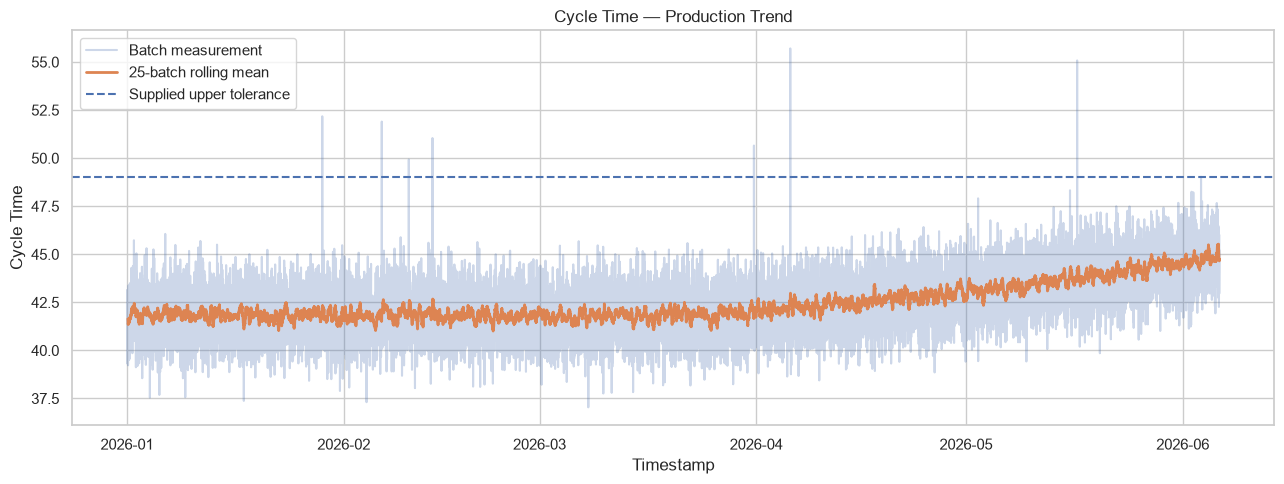

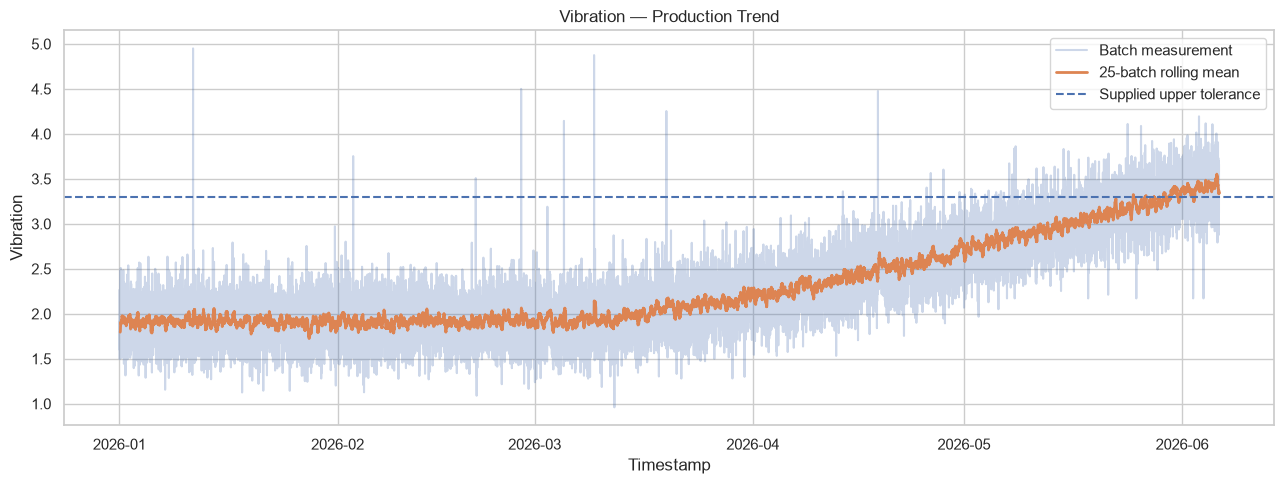

In [16]:
if timestamp_col and available_process:
    for concept, col in available_process.items():

        if not pd.api.types.is_numeric_dtype(df[col]):
            continue

        rolling = df[col].rolling(
            ROLLING_WINDOW,
            min_periods=max(5, ROLLING_WINDOW // 2)
        ).mean()

        plt.figure(figsize=(13, 5))
        plt.plot(
            df[timestamp_col],
            df[col],
            alpha=0.28,
            label="Batch measurement"
        )
        plt.plot(
            df[timestamp_col],
            rolling,
            linewidth=2,
            label=f"{ROLLING_WINDOW}-batch rolling mean"
        )

        tolerance_col = COLUMN_MAP.get(
            TOLERANCE_CONCEPTS.get(concept, "")
        )

        if tolerance_col and tolerance_col in df.columns:
            plt.axhline(
                df[tolerance_col].iloc[0],
                linestyle="--",
                linewidth=1.5,
                label="Supplied upper tolerance"
            )

        plt.title(f"{concept.replace('_', ' ').title()} — Production Trend")
        plt.xlabel("Timestamp")
        plt.ylabel(col.replace("_", " ").title())
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("Timestamp or process variables unavailable — timeline skipped.")


# 17 · Rolling Z-Score Drift Flags


,variable,mean_abs_rolling_z,max_abs_rolling_z,flagged_batches,flag_rate_%
2,cycle_time,0.789,4.447,18,0.120
1,pressure,0.789,4.419,19,0.127
0,temperature,0.784,4.595,26,0.173
3,vibration,0.783,4.531,27,0.180


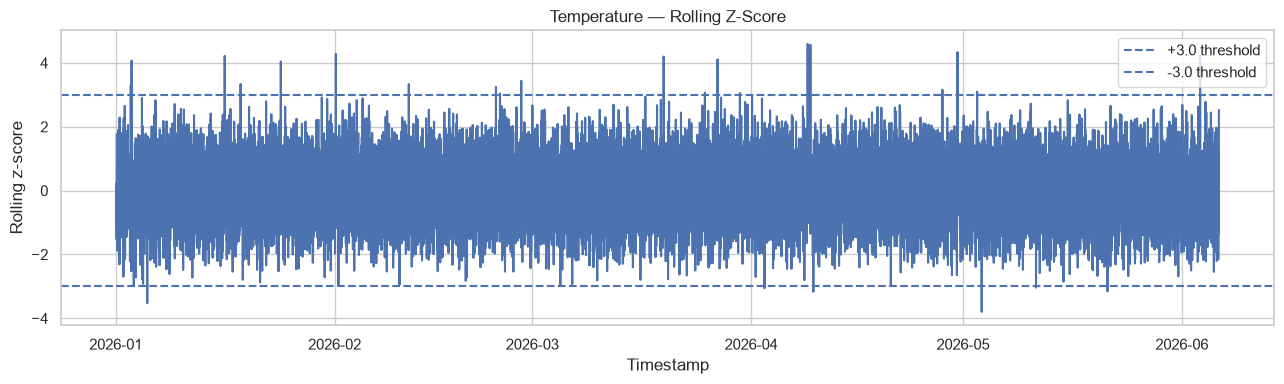

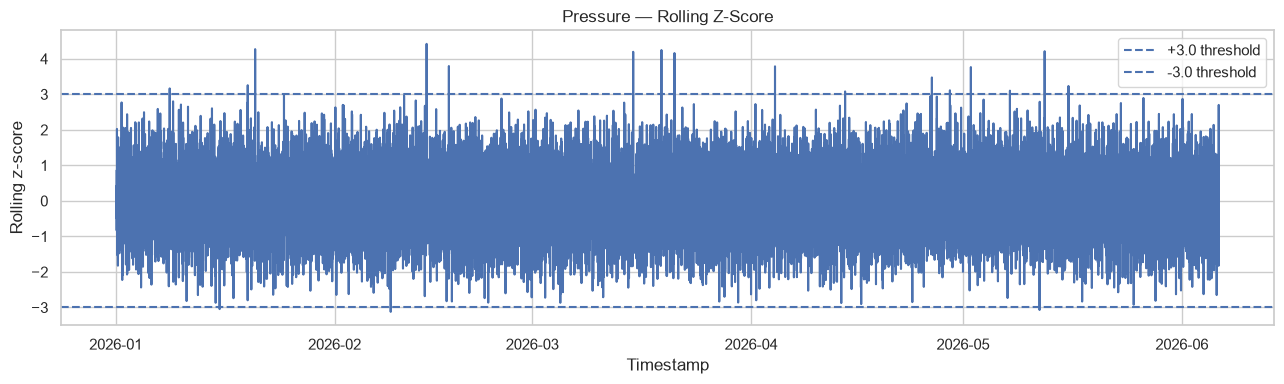

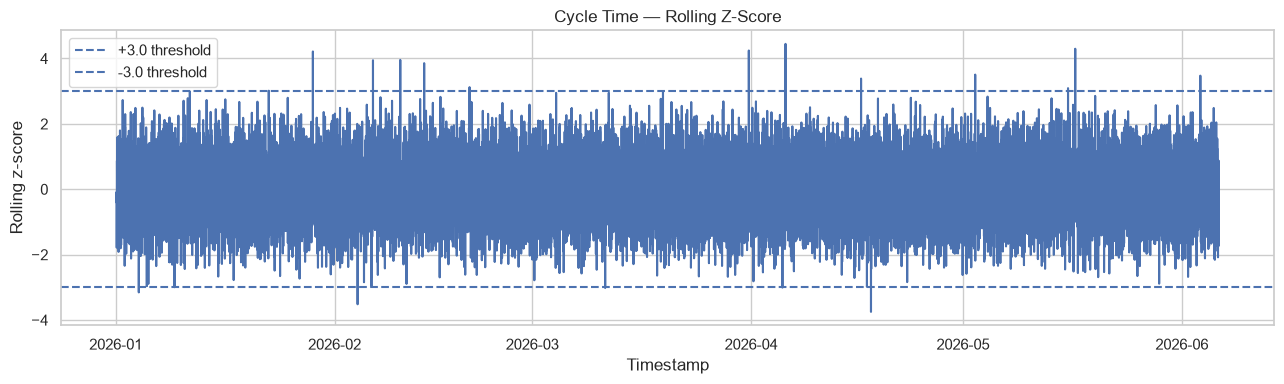

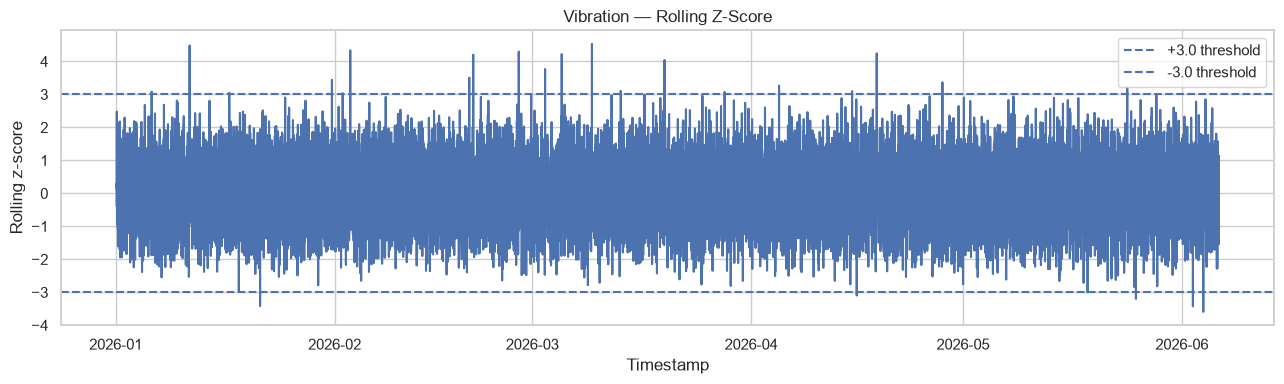

In [17]:
drift_rows = []

for concept, col in available_process.items():

    if not pd.api.types.is_numeric_dtype(df[col]):
        continue

    mean_col = f"{concept}_rolling_mean"
    std_col = f"{concept}_rolling_std"
    z_col = f"{concept}_rolling_z"
    flag_col = f"{concept}_drift_flag"

    min_periods = max(5, ROLLING_WINDOW // 2)

    df[mean_col] = df[col].rolling(
        ROLLING_WINDOW,
        min_periods=min_periods
    ).mean()

    df[std_col] = df[col].rolling(
        ROLLING_WINDOW,
        min_periods=min_periods
    ).std()

    df[z_col] = (
        (df[col] - df[mean_col]) /
        df[std_col].replace(0, np.nan)
    )

    df[flag_col] = df[z_col].abs() >= Z_THRESHOLD

    drift_rows.append({
        "variable": concept,
        "mean_abs_rolling_z": df[z_col].abs().mean(),
        "max_abs_rolling_z": df[z_col].abs().max(),
        "flagged_batches": int(df[flag_col].sum()),
        "flag_rate_%": df[flag_col].mean() * 100,
    })

if drift_rows:
    drift_report = pd.DataFrame(drift_rows).sort_values(
        "mean_abs_rolling_z",
        ascending=False
    )

    display(drift_report.round(3))

    for concept in available_process:
        z_col = f"{concept}_rolling_z"

        if z_col not in df.columns:
            continue

        x_axis = df[timestamp_col] if timestamp_col else np.arange(len(df))

        plt.figure(figsize=(13, 4))
        plt.plot(x_axis, df[z_col])
        plt.axhline(
            Z_THRESHOLD,
            linestyle="--",
            linewidth=1.5,
            label=f"+{Z_THRESHOLD} threshold"
        )
        plt.axhline(
            -Z_THRESHOLD,
            linestyle="--",
            linewidth=1.5,
            label=f"-{Z_THRESHOLD} threshold"
        )

        plt.title(f"{concept.replace('_', ' ').title()} — Rolling Z-Score")
        plt.xlabel("Timestamp" if timestamp_col else "Batch order")
        plt.ylabel("Rolling z-score")
        plt.legend()
        plt.tight_layout()
        plt.show()
else:
    print("No numeric process variables available for drift analysis.")


# 18 · Drift Flag Summary



In [18]:
monitor_cols = []

for concept in ["batch_id", "timestamp", "machine_id", "product_line"]:
    col = COLUMN_MAP.get(concept)
    if col and col not in monitor_cols:
        monitor_cols.append(col)

for concept, col in available_process.items():
    if col not in monitor_cols:
        monitor_cols.append(col)

for concept, col in available_quality.items():
    if col not in monitor_cols:
        monitor_cols.append(col)

for concept in ["actual_status", "final_outcome"]:
    col = COLUMN_MAP.get(concept)
    if col and col not in monitor_cols:
        monitor_cols.append(col)

flag_cols = [
    f"{concept}_drift_flag"
    for concept in available_process
    if f"{concept}_drift_flag" in df.columns
]

monitor_cols.extend([c for c in flag_cols if c not in monitor_cols])

if monitor_cols:
    display(df[monitor_cols].tail(20))
else:
    print("No monitoring columns were detected.")

,batch_id,timestamp,machine_id,product_line,temperature,pressure,cycle_time,vibration,quality_measurement,defect_rate,actual_status,final_outcome,temperature_drift_flag,pressure_drift_flag,cycle_time_drift_flag,vibration_drift_flag
14972,14981,2026-06-06 01:00:00,M-02,Line-D,75.013,104.963,46.268,3.542,43.161,5.247,Critical,Rejected,False,False,False,False
14973,14982,2026-06-06 01:15:00,M-06,Line-B,73.642,103.154,45.505,3.343,44.966,3.986,Critical,Rejected,False,False,False,False
14974,14983,2026-06-06 01:30:00,M-03,Line-C,75.450,104.864,43.068,3.111,45.360,4.124,Critical,Rejected,False,False,False,False
14975,14984,2026-06-06 01:45:00,M-06,Line-D,74.273,103.246,46.395,3.299,44.978,4.274,Critical,Rejected,False,False,False,False
14976,14985,2026-06-06 02:00:00,M-02,Line-C,76.790,104.797,46.043,3.404,42.587,5.394,Critical,Rejected,False,False,False,False
14977,14986,2026-06-06 02:15:00,M-05,Line-A,75.702,102.741,46.475,3.906,42.637,5.547,Critical,Rejected,False,False,False,False
14978,14987,2026-06-06 02:30:00,M-01,Line-A,74.042,103.874,44.420,3.106,46.750,3.413,Warning,Rework,False,False,False,False
14979,14988,2026-06-06 02:45:00,M-01,Line-C,74.495,104.259,42.727,3.533,46.725,4.287,Critical,Rejected,False,False,False,False
14980,14989,2026-06-06 03:00:00,M-01,Line-C,74.864,104.064,43.414,3.176,46.022,3.865,Critical,Rejected,False,False,False,False
14981,14990,2026-06-06 03:15:00,M-06,Line-C,77.086,104.184,43.084,3.733,41.912,5.058,Critical,Rejected,False,False,False,False



# 19 · Final EDA Summary



In [19]:
print("=" * 78)
print("🏭 PRODUCTION QUALITY DRIFT DETECTOR — FINAL EDA SUMMARY")
print("=" * 78)

print(f"\n📁 Source file: {os.path.basename(DATA_PATH)}")
print(f"📦 Raw shape: {len(df_raw):,} × {df_raw.shape[1]:,}")
print(f"🧹 Clean shape: {len(df):,} × {df.shape[1]:,}")
print(f"🗑️ Rows removed: {len(df_raw) - len(df):,}")
print(f"🔁 Remaining duplicates: {df.duplicated().sum():,}")
print(f"❓ Remaining missing cells: {df.isna().sum().sum():,}")

print("\n🔧 Process variables detected:")
if available_process:
    for concept, col in available_process.items():
        print(f"   ✓ {concept}: {col}")
else:
    print("   None")

print("\n📊 Quality variables detected:")
if available_quality:
    for concept, col in available_quality.items():
        print(f"   ✓ {concept}: {col}")
else:
    print("   None")

if "drift_report" in globals() and not drift_report.empty:
    print("\n🚨 Drift exploration:")
    for _, row in drift_report.iterrows():
        print(
            f"   • {row['variable']}: "
            f"mean |rolling z|={row['mean_abs_rolling_z']:.2f}, "
            f"flags={int(row['flagged_batches'])}"
        )

print("\n✓ Universal EDA + production analysis complete.")

🏭 PRODUCTION QUALITY DRIFT DETECTOR — FINAL EDA SUMMARY

📁 Source file: Data_raw.csv
📦 Raw shape: 15,012 × 23
🧹 Clean shape: 14,992 × 47
🗑️ Rows removed: 20
🔁 Remaining duplicates: 0
❓ Remaining missing cells: 132

🔧 Process variables detected:
   ✓ temperature: temperature
   ✓ pressure: pressure
   ✓ cycle_time: cycle_time
   ✓ vibration: vibration

📊 Quality variables detected:
   ✓ quality_measurement: quality_measurement
   ✓ defect_rate: defect_rate

🚨 Drift exploration:
   • cycle_time: mean |rolling z|=0.79, flags=18
   • pressure: mean |rolling z|=0.79, flags=19
   • temperature: mean |rolling z|=0.78, flags=26
   • vibration: mean |rolling z|=0.78, flags=27

✓ Universal EDA + production analysis complete.



# 20 · Export Clean Dataset



In [20]:
df.to_csv(CLEANED_OUTPUT, index=False)

print(f"✓ Clean dataset saved: {CLEANED_OUTPUT}")
print(f"✓ Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

✓ Clean dataset saved: d:\Sarthak's Folder\Project\Hackathon\Data\Data_cleaned.csv
✓ Shape: 14,992 rows × 47 columns


# PHASE 2 — FEATURE ENGINEERING

Transform cleaned production measurements into rolling statistics, deviations, trend/change signals, tolerance features, and quality/defect features. Export `Data_features.csv`.


In [21]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

ALIASES = {
    "batch_id": ["batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"],
    "timestamp": ["timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"],
    "machine_id": ["machine_id", "machine", "machine_no", "machine_number", "equipment_id"],
    "product_line": ["product_line", "production_line", "line", "line_id", "product"],
    "temperature": ["temperature", "temp", "temp_c", "temperature_c", "temperature_celsius"],
    "pressure": ["pressure", "press", "pressure_psi", "pressure_bar"],
    "cycle_time": ["cycle_time", "cycle_duration", "cycle_time_sec", "duration", "processing_time"],
    "vibration": ["vibration", "vibration_level", "vibration_mm_s", "vibration_rms"],
    "quality_measurement": ["quality_measurement", "quality_score", "quality", "quality_index"],
    "defect_rate": ["defect_rate", "defect_percentage", "defect_pct", "defect_ratio"],
    "actual_status": ["actual_status", "status", "process_status", "quality_status", "condition"],
    "final_outcome": ["final_outcome", "outcome", "result", "final_result", "decision"],
    "temperature_tolerance": ["temperature_tolerance", "temp_tolerance", "temperature_limit", "temp_limit"],
    "pressure_tolerance": ["pressure_tolerance", "pressure_limit", "pressure_upper_limit"],
    "cycle_time_tolerance": ["cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit"],
    "vibration_tolerance": ["vibration_tolerance", "vibration_limit", "vibration_upper_limit"]
}

def detect_column(concept):
    normalized = {normalize_name(c): c for c in df.columns}
    for alias in ALIASES.get(concept, []):
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]
    return None

COLUMN_MAP = {concept: detect_column(concept) for concept in ALIASES}
display(pd.DataFrame([{"concept": k, "column": v or "NOT FOUND"} for k, v in COLUMN_MAP.items()]))


,concept,column
0,batch_id,batch_id
1,timestamp,timestamp
2,machine_id,machine_id
3,product_line,product_line
4,temperature,temperature
5,pressure,pressure
6,cycle_time,cycle_time
7,vibration,vibration
8,quality_measurement,quality_measurement
9,defect_rate,defect_rate


# 01 · Prepare Production Order


In [22]:
timestamp_col = COLUMN_MAP.get("timestamp")
batch_col = COLUMN_MAP.get("batch_id")

if timestamp_col:
    df[timestamp_col] = pd.to_datetime(df[timestamp_col], errors="coerce")
    df = df.dropna(subset=[timestamp_col]).sort_values(timestamp_col).reset_index(drop=True)
elif batch_col:
    df = df.sort_values(batch_col).reset_index(drop=True)
else:
    df = df.reset_index(drop=True)

df["_sequence"] = np.arange(len(df))
print(f"Ordered observations: {len(df):,}")


Ordered observations: 14,992


# 02 · Detect Core Process Variables


In [23]:
PROCESS_CONCEPTS = ["temperature", "pressure", "cycle_time", "vibration"]

available_process = {
    concept: COLUMN_MAP[concept]
    for concept in PROCESS_CONCEPTS
    if COLUMN_MAP.get(concept)
}

for concept in PROCESS_CONCEPTS:
    print(f"{concept}: {available_process.get(concept, 'NOT FOUND')}")


temperature: temperature
pressure: pressure
cycle_time: cycle_time
vibration: vibration


# 03 · Rolling Statistics


In [24]:
ROLLING_WINDOW = 25
MIN_PERIODS = max(5, ROLLING_WINDOW // 2)

for concept, col in available_process.items():
    value = pd.to_numeric(df[col], errors="coerce")
    df[f"{concept}_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()
    df[f"{concept}_rolling_std"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).std()
    df[f"{concept}_rolling_variance"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).var()
    df[f"{concept}_deviation"] = value - df[f"{concept}_rolling_mean"]
    df[f"{concept}_rolling_z"] = df[f"{concept}_deviation"] / df[f"{concept}_rolling_std"].replace(0, np.nan)

print("Rolling features created.")


Rolling features created.


# 04 · Change Features


In [25]:
for concept, col in available_process.items():
    value = pd.to_numeric(df[col], errors="coerce")
    df[f"{concept}_change"] = value.diff()
    df[f"{concept}_pct_change"] = value.pct_change() * 100
    df[f"{concept}_baseline_pct_change"] = (
        (value - df[f"{concept}_rolling_mean"])
        / df[f"{concept}_rolling_mean"].replace(0, np.nan)
        * 100
    )

print("Change features created.")


Change features created.


# 05 · Tolerance Features


In [26]:
TOLERANCE_PAIRS = {
    "temperature": "temperature_tolerance",
    "pressure": "pressure_tolerance",
    "cycle_time": "cycle_time_tolerance",
    "vibration": "vibration_tolerance"
}

for concept, tolerance_concept in TOLERANCE_PAIRS.items():
    value_col = COLUMN_MAP.get(concept)
    tolerance_col = COLUMN_MAP.get(tolerance_concept)

    if not value_col or not tolerance_col:
        continue

    value = pd.to_numeric(df[value_col], errors="coerce")
    tolerance = pd.to_numeric(df[tolerance_col], errors="coerce")

    df[f"{concept}_tolerance_distance"] = tolerance - value
    df[f"{concept}_tolerance_utilization_pct"] = value / tolerance.replace(0, np.nan) * 100
    df[f"{concept}_near_limit"] = df[f"{concept}_tolerance_utilization_pct"] >= 90

print("Tolerance features created.")


Tolerance features created.


# 06 · Quality and Defect Features

In [27]:
quality_col = COLUMN_MAP.get("quality_measurement")
defect_col = COLUMN_MAP.get("defect_rate")

if quality_col:
    value = pd.to_numeric(df[quality_col], errors="coerce")
    df["quality_change"] = value.diff()
    df["quality_pct_change"] = value.pct_change() * 100
    df["quality_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()

if defect_col:
    value = pd.to_numeric(df[defect_col], errors="coerce")
    df["defect_rate_change"] = value.diff()
    df["defect_rate_pct_change"] = value.pct_change() * 100
    df["defect_rate_rolling_mean"] = value.rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()

print("Quality and defect features created.")


Quality and defect features created.


# 07 · Feature Audit

In [28]:
feature_cols = [
    c for c in df.columns
    if any(token in c for token in [
        "_rolling_", "_change", "_pct_change", "_deviation",
        "_tolerance_", "_near_limit", "_baseline_"
    ])
]

feature_audit = pd.DataFrame({
    "feature": feature_cols,
    "dtype": [str(df[c].dtype) for c in feature_cols],
    "missing": [int(df[c].isna().sum()) for c in feature_cols],
    "unique": [int(df[c].nunique(dropna=True)) for c in feature_cols]
})

display(feature_audit)


,feature,dtype,missing,unique
0,temperature_tolerance_distance,float64,0,6839
1,pressure_tolerance_distance,float64,0,7102
2,cycle_time_tolerance_distance,float64,0,5679
3,vibration_tolerance_distance,float64,0,2371
4,temperature_rolling_mean,float64,11,13834
5,temperature_rolling_std,float64,11,14978
6,temperature_rolling_z,float64,11,14981
7,pressure_rolling_mean,float64,11,13953
8,pressure_rolling_std,float64,11,14980
9,pressure_rolling_z,float64,11,14981


# 08 · Feature Visualization

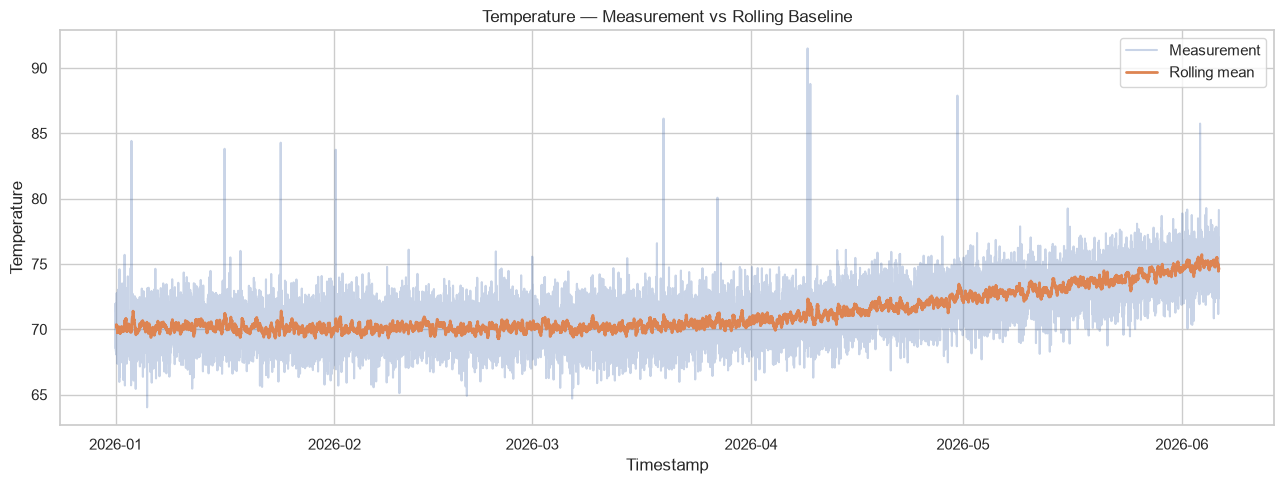

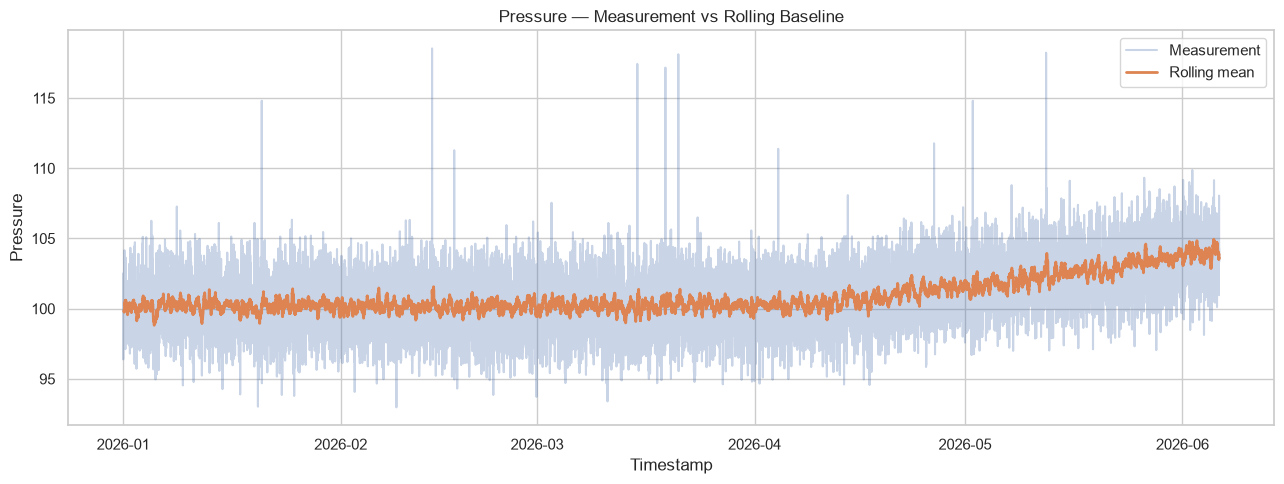

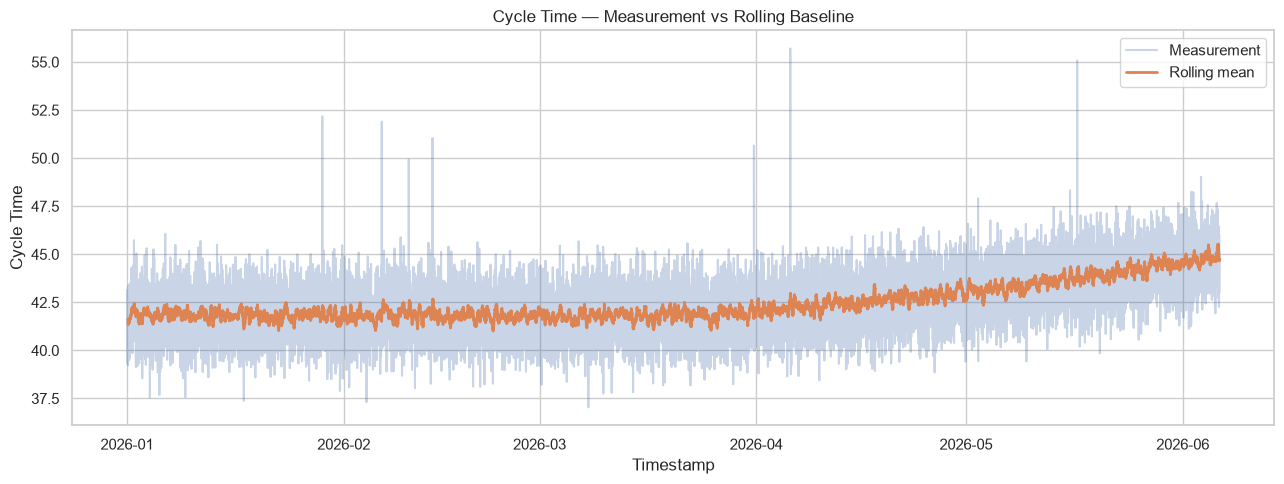

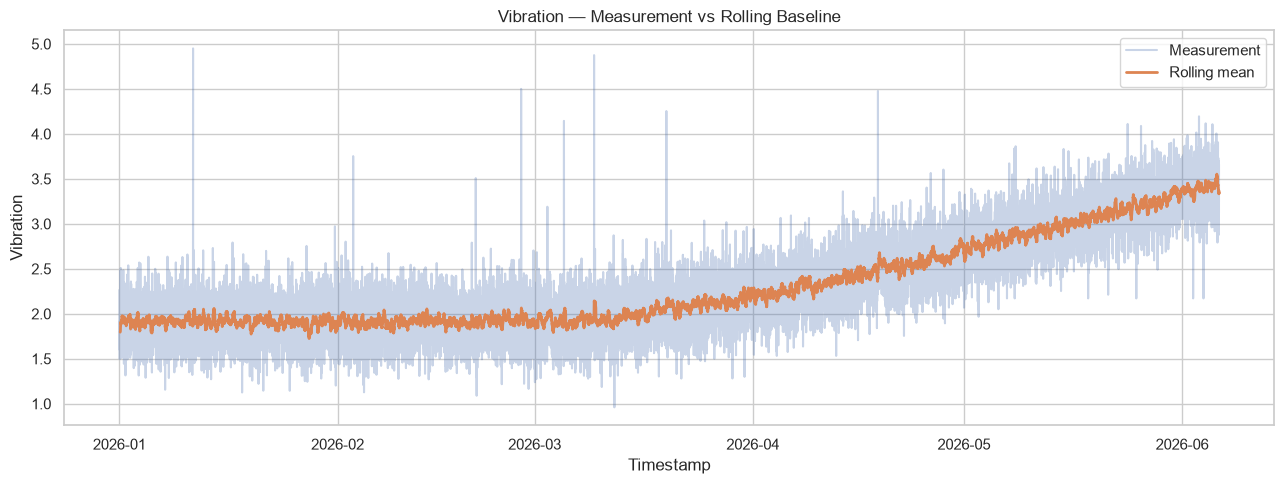

In [29]:
for concept, col in available_process.items():
    x = df[timestamp_col] if timestamp_col and timestamp_col in df.columns else df["_sequence"]

    plt.figure(figsize=(13, 5))
    plt.plot(x, df[col], alpha=0.30, label="Measurement")
    plt.plot(x, df[f"{concept}_rolling_mean"], linewidth=2, label="Rolling mean")
    plt.title(f"{concept.replace('_', ' ').title()} — Measurement vs Rolling Baseline")
    plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
    plt.ylabel(col.replace("_", " ").title())
    plt.legend()
    plt.tight_layout()
    plt.show()


# 09 · Export Feature Dataset

In [30]:
output_path = Path(DATA_PATH).parent / "Data_features.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")


Saved: d:\Sarthak's Folder\Project\Hackathon\Data\Data_features.csv
Shape: 14,992 rows × 82 columns


---

## Phase 2 Complete → Continue to Phase 3


# PHASE 3 — DRIFT DETECTION



In [31]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

ALIASES = {
    "batch_id": ["batch_id", "batch", "batch_number", "batch_no", "lot_id", "lot_number"],
    "timestamp": ["timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"],
    "machine_id": ["machine_id", "machine", "machine_no", "machine_number", "equipment_id"],
    "product_line": ["product_line", "production_line", "line", "line_id", "product"],
    "temperature": ["temperature", "temp", "temp_c", "temperature_c", "temperature_celsius"],
    "pressure": ["pressure", "press", "pressure_psi", "pressure_bar"],
    "cycle_time": ["cycle_time", "cycle_duration", "cycle_time_sec", "duration", "processing_time"],
    "vibration": ["vibration", "vibration_level", "vibration_mm_s", "vibration_rms"],
    "quality_measurement": ["quality_measurement", "quality_score", "quality", "quality_index"],
    "defect_rate": ["defect_rate", "defect_percentage", "defect_pct", "defect_ratio"],
    "actual_status": ["actual_status", "status", "process_status", "quality_status", "condition"],
    "final_outcome": ["final_outcome", "outcome", "result", "final_result", "decision"],
    "temperature_tolerance": ["temperature_tolerance", "temp_tolerance", "temperature_limit", "temp_limit"],
    "pressure_tolerance": ["pressure_tolerance", "pressure_limit", "pressure_upper_limit"],
    "cycle_time_tolerance": ["cycle_time_tolerance", "cycle_tolerance", "cycle_time_limit"],
    "vibration_tolerance": ["vibration_tolerance", "vibration_limit", "vibration_upper_limit"]
}

def detect_column(concept):
    normalized = {normalize_name(c): c for c in df.columns}
    for alias in ALIASES.get(concept, []):
        key = normalize_name(alias)
        if key in normalized:
            return normalized[key]
    return None

COLUMN_MAP = {concept: detect_column(concept) for concept in ALIASES}
display(pd.DataFrame([{"concept": k, "column": v or "NOT FOUND"} for k, v in COLUMN_MAP.items()]))


,concept,column
0,batch_id,batch_id
1,timestamp,timestamp
2,machine_id,machine_id
3,product_line,product_line
4,temperature,temperature
5,pressure,pressure
6,cycle_time,cycle_time
7,vibration,vibration
8,quality_measurement,quality_measurement
9,defect_rate,defect_rate


# 01 · Detection Configuration

In [32]:
Z_THRESHOLD = 3.0
WARNING_SCORE = 0.30
CRITICAL_SCORE = 0.60
NEAR_LIMIT_PCT = 90.0

PROCESS_CONCEPTS = ["temperature", "pressure", "cycle_time", "vibration"]

available_process = {
    concept: COLUMN_MAP[concept]
    for concept in PROCESS_CONCEPTS
    if COLUMN_MAP.get(concept)
}

print("Detected process variables:")
for concept, col in available_process.items():
    print(f"{concept}: {col}")


Detected process variables:
temperature: temperature
pressure: pressure
cycle_time: cycle_time
vibration: vibration


# 02 · Statistical Signals

In [33]:
for concept, col in available_process.items():
    z_col = f"{concept}_rolling_z"

    if z_col not in df.columns:
        value = pd.to_numeric(df[col], errors="coerce")
        mean = value.rolling(25, min_periods=12).mean()
        std = value.rolling(25, min_periods=12).std()
        df[z_col] = (value - mean) / std.replace(0, np.nan)

    df[f"{concept}_z_signal"] = (df[z_col].abs() >= Z_THRESHOLD).astype(int)

print("Statistical signals created.")


Statistical signals created.


# 03 · Tolerance Signals

In [34]:
for concept in available_process:
    utilization_col = f"{concept}_tolerance_utilization_pct"
    distance_col = f"{concept}_tolerance_distance"

    if utilization_col in df.columns:
        df[f"{concept}_tolerance_signal"] = (
            df[utilization_col] >= NEAR_LIMIT_PCT
        ).astype(int)
    elif distance_col in df.columns:
        df[f"{concept}_tolerance_signal"] = (
            df[distance_col] <= 0
        ).astype(int)

print("Tolerance signals created.")


Tolerance signals created.


# 04 · Directional Drift

In [35]:
for concept in available_process:
    mean_col = f"{concept}_rolling_mean"
    std_col = f"{concept}_rolling_std"

    if mean_col not in df.columns or std_col not in df.columns:
        continue

    previous = df[mean_col].shift(25)
    df[f"{concept}_mean_shift"] = df[mean_col] - previous

    df[f"{concept}_directional_signal"] = (
        df[f"{concept}_mean_shift"].abs() >
        df[std_col].replace(0, np.nan)
    ).astype(int)

print("Directional signals created.")


Directional signals created.


# 05 · Quality and Defect Support

In [36]:
df["defect_signal"] = (
    df["defect_rate_pct_change"] > 10
).astype(int) if "defect_rate_pct_change" in df.columns else 0

df["quality_signal"] = (
    df["quality_pct_change"] < -10
).astype(int) if "quality_pct_change" in df.columns else 0

print("Quality and defect support signals created.")


Quality and defect support signals created.


# 06 · Variable Drift Scores

In [37]:
variable_scores = []

for concept in available_process:
    cols = [
        f"{concept}_z_signal",
        f"{concept}_tolerance_signal",
        f"{concept}_directional_signal"
    ]
    cols = [c for c in cols if c in df.columns]

    if cols:
        score_col = f"{concept}_drift_score"
        df[score_col] = df[cols].mean(axis=1)
        variable_scores.append(score_col)

print("Variable score columns:")
print(variable_scores)


Variable score columns:
['temperature_drift_score', 'pressure_drift_score', 'cycle_time_drift_score', 'vibration_drift_score']


# 07 · Overall Drift Score

In [38]:
if variable_scores:
    df["process_drift_score"] = df[variable_scores].mean(axis=1)
else:
    df["process_drift_score"] = 0.0

supporting = df[["defect_signal", "quality_signal"]].mean(axis=1)

df["drift_score"] = (
    0.80 * df["process_drift_score"] +
    0.20 * supporting
).clip(0, 1)

display(df["drift_score"].describe().to_frame("drift_score").round(4))


,drift_score
count,"14,992.000"
mean,0.172
std,0.085
min,0.000
25%,0.133
50%,0.167
75%,0.233
max,0.600


# 08 · Stable / Warning / Critical

In [39]:
df["detected_status"] = np.select(
    [
        df["drift_score"] >= CRITICAL_SCORE,
        df["drift_score"] >= WARNING_SCORE
    ],
    [
        "Critical",
        "Warning"
    ],
    default="Stable"
)

status_summary = (
    df["detected_status"]
    .value_counts()
    .rename_axis("status")
    .reset_index(name="batch_count")
)

status_summary["percentage"] = status_summary["batch_count"] / len(df) * 100
display(status_summary.round(2))


,status,batch_count,percentage
0,Stable,13438,89.630
1,Warning,1553,10.360
2,Critical,1,0.010


# 09 · Variable Responsibility

In [40]:
if variable_scores:
    variable_report = pd.DataFrame({
        "variable": [c.replace("_drift_score", "") for c in variable_scores],
        "mean_drift_score": [df[c].mean() for c in variable_scores],
        "max_drift_score": [df[c].max() for c in variable_scores],
        "high_score_observations": [int((df[c] >= 0.60).sum()) for c in variable_scores]
    }).sort_values("mean_drift_score", ascending=False)

    display(variable_report.round(4))
else:
    variable_report = pd.DataFrame()
    print("No variable-level scores available.")


,variable,mean_drift_score,max_drift_score,high_score_observations
1,pressure,0.320,0.667,53
0,temperature,0.221,0.667,32
3,vibration,0.051,0.667,31
2,cycle_time,0.049,0.667,15


# 10 · Drift Timeline

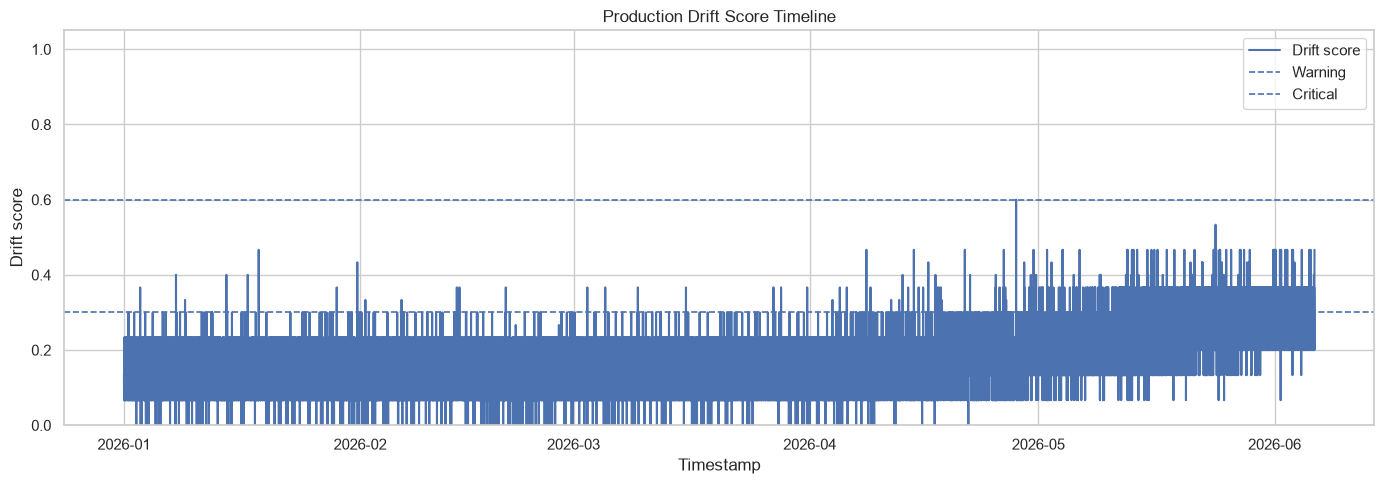

In [41]:
timestamp_col = COLUMN_MAP.get("timestamp")
x = (
    pd.to_datetime(df[timestamp_col], errors="coerce")
    if timestamp_col and timestamp_col in df.columns
    else np.arange(len(df))
)

plt.figure(figsize=(14, 5))
plt.plot(x, df["drift_score"], linewidth=1.5, label="Drift score")
plt.axhline(WARNING_SCORE, linestyle="--", linewidth=1.2, label="Warning")
plt.axhline(CRITICAL_SCORE, linestyle="--", linewidth=1.2, label="Critical")
plt.title("Production Drift Score Timeline")
plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
plt.ylabel("Drift score")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


# 11 · Optional Isolation Forest

In [42]:
try:
    from sklearn.ensemble import IsolationForest

    model_cols = [
        col for col in available_process.values()
        if col in df.columns and pd.api.types.is_numeric_dtype(df[col])
    ]

    if model_cols:
        model_data = df[model_cols].replace([np.inf, -np.inf], np.nan)
        model_data = model_data.fillna(model_data.median())

        model = IsolationForest(
            n_estimators=200,
            contamination="auto",
            random_state=42
        )

        predictions = model.fit_predict(model_data)
        scores = model.decision_function(model_data)

        df["isolation_forest_anomaly"] = (predictions == -1).astype(int)
        df["isolation_forest_score"] = -scores

        print("Isolation Forest completed.")
    else:
        print("No numeric process variables available.")
except ImportError:
    print("scikit-learn is not installed.")


Isolation Forest completed.


# 12 · Export Drift Results

In [43]:
output_path = Path(DATA_PATH).parent / "Data_drift_results.csv"
df.to_csv(output_path, index=False)
print(f"Saved: {output_path}")


Saved: d:\Sarthak's Folder\Project\Hackathon\Data\Data_drift_results.csv


# PHASE 4 — MODEL EVALUATION

Compare detector predictions with the dataset's ground-truth status when available and calculate accuracy, precision, recall, F1, false-positive rate, confusion matrix, three-state accuracy, detection delay, and variable-level evidence.


In [44]:
def find_data_file(filename):
    paths = [
        Path.cwd() / "Data" / filename,
        Path.cwd().parent / "Data" / filename
    ]

    for path in paths:
        if path.is_file():
            return path.resolve()

    raise FileNotFoundError(f"{filename} was not found in the project Data folder.")

DATA_PATH = find_data_file("Data_drift_results.csv")
df = pd.read_csv(DATA_PATH)

print(f"Loaded: {DATA_PATH}")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

Loaded: D:\Sarthak's Folder\Project\Hackathon\Data\Data_drift_results.csv
Shape: 14,992 rows × 109 columns


# 01 · Identify Ground Truth

In [45]:
def normalize_name(name):
    name = str(name).strip().lower()
    name = re.sub(r"[%/()\-]+", "_", name)
    name = re.sub(r"[^a-z0-9_]+", "_", name)
    return re.sub(r"_+", "_", name).strip("_")

normalized = {normalize_name(c): c for c in df.columns}

ground_truth_aliases = [
    "actual_status",
    "actual_drift",
    "drift_label",
    "ground_truth",
    "scripted_drift",
    "is_drift",
    "drift_ground_truth",
    "process_status",
    "quality_status",
    "condition"
]

excluded_truth_columns = {
    "detected_status",
    "predicted_drift",
    "drift_score",
    "process_drift_score"
}

ground_truth_col = None

for alias in ground_truth_aliases:
    key = normalize_name(alias)
    if key in normalized and normalized[key] not in excluded_truth_columns:
        ground_truth_col = normalized[key]
        break

print(f"Ground truth column: {ground_truth_col or 'NOT FOUND'}")

if ground_truth_col:
    print(df[ground_truth_col].value_counts(dropna=False))

Ground truth column: actual_status
actual_status
Stable      9780
Warning     3514
Critical    1698
Name: count, dtype: int64


# 02 · Identify Detector Output

In [46]:
detected_col = "detected_status" if "detected_status" in df.columns else None
score_col = "drift_score" if "drift_score" in df.columns else None

print(f"Status output: {detected_col or 'NOT FOUND'}")
print(f"Score output: {score_col or 'NOT FOUND'}")

if not detected_col and not score_col:
    raise ValueError("No drift detector output exists in the results dataset.")

Status output: detected_status
Score output: drift_score


# 03 · Convert Ground Truth to Binary Drift


In [47]:
def to_binary_truth(series):
    if pd.api.types.is_bool_dtype(series):
        return series.astype(int)

    values = series.astype("string").str.strip().str.lower()

    numeric = pd.to_numeric(values, errors="coerce")
    numeric_ratio = numeric.notna().mean()

    if numeric_ratio >= 0.90:
        return (numeric.fillna(0) > 0).astype(int)

    positive = {
        "1", "true", "yes", "y", "drift",
        "anomaly", "abnormal", "critical", "warning"
    }

    return values.isin(positive).astype(int)

if ground_truth_col:
    df["actual_drift"] = to_binary_truth(df[ground_truth_col])
    display(df["actual_drift"].value_counts().sort_index().rename(index={0: "No Drift", 1: "Drift"}).to_frame("count"))
else:
    df["actual_drift"] = np.nan
    print("No ground truth label was found. Classification metrics will not be reported.")

,count
actual_drift,
No Drift,9780
Drift,5212


# 04 · Convert Detector Output to Binary Prediction

In [48]:
if detected_col:
    df["predicted_drift"] = (
        df[detected_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .isin(["warning", "critical"])
        .astype(int)
    )
else:
    df["predicted_drift"] = (pd.to_numeric(df[score_col], errors="coerce").fillna(0) >= 0.30).astype(int)

display(
    df["predicted_drift"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No Drift", 1: "Drift"})
    .to_frame("count")
)

,count
predicted_drift,
No Drift,13438
Drift,1554


# 05 · Classification Metrics


In [49]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

if ground_truth_col:
    valid = df[["actual_drift", "predicted_drift"]].dropna()
    y_true = valid["actual_drift"].astype(int)
    y_pred = valid["predicted_drift"].astype(int)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    fpr = fp / (fp + tn) if (fp + tn) else 0.0

    metrics = pd.DataFrame({
        "metric": [
            "accuracy",
            "precision",
            "recall",
            "f1",
            "false_positive_rate",
            "true_positive",
            "false_positive",
            "false_negative",
            "true_negative"
        ],
        "value": [
            accuracy,
            precision,
            recall,
            f1,
            fpr,
            tp,
            fp,
            fn,
            tn
        ]
    })

    display(metrics.round(4))

    print(classification_report(
        y_true,
        y_pred,
        target_names=["No Drift", "Drift"],
        zero_division=0
    ))
else:
    metrics = pd.DataFrame(columns=["metric", "value"])
    accuracy = precision = recall = f1 = fpr = np.nan
    tn = fp = fn = tp = np.nan

,metric,value
0,accuracy,0.742
1,precision,0.932
2,recall,0.278
3,f1,0.428
4,false_positive_rate,0.011
5,true_positive,"1,448.000"
6,false_positive,106.000
7,false_negative,"3,764.000"
8,true_negative,"9,674.000"


              precision    recall  f1-score   support

    No Drift       0.72      0.99      0.83      9780
       Drift       0.93      0.28      0.43      5212

    accuracy                           0.74     14992
   macro avg       0.83      0.63      0.63     14992
weighted avg       0.79      0.74      0.69     14992



# 06 · Three-State Performance

In [50]:
state_metrics = pd.DataFrame()

if ground_truth_col and detected_col:
    actual_state = df[ground_truth_col].astype("string").str.strip().str.title()
    predicted_state = df[detected_col].astype("string").str.strip().str.title()

    valid_state = pd.DataFrame({
        "actual": actual_state,
        "predicted": predicted_state
    }).dropna()

    if len(valid_state):
        state_accuracy = (valid_state["actual"] == valid_state["predicted"]).mean()

        state_metrics = pd.DataFrame({
            "metric": ["three_state_accuracy"],
            "value": [state_accuracy]
        })

        print(f"Three-state accuracy: {state_accuracy:.4f}")
        print()
        print(classification_report(
            valid_state["actual"],
            valid_state["predicted"],
            labels=["Stable", "Warning", "Critical"],
            zero_division=0
        ))

Three-state accuracy: 0.6803

              precision    recall  f1-score   support

      Stable       0.72      0.99      0.83      9780
     Warning       0.34      0.15      0.21      3514
    Critical       1.00      0.00      0.00      1698

    accuracy                           0.68     14992
   macro avg       0.69      0.38      0.35     14992
weighted avg       0.66      0.68      0.59     14992



# 07 · Confusion Matrix

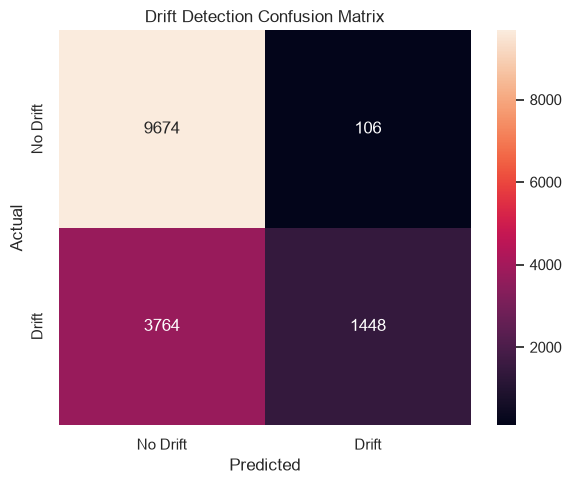

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

if ground_truth_col:
    cm = confusion_matrix(df["actual_drift"].astype(int), df["predicted_drift"].astype(int), labels=[0, 1])

    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No Drift", "Drift"],
        yticklabels=["No Drift", "Drift"]
    )
    plt.title("Drift Detection Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

# 08 · Detection Delay


In [52]:
if ground_truth_col:
    actual_positions = np.flatnonzero(df["actual_drift"].to_numpy(dtype=int) == 1)
    predicted_positions = np.flatnonzero(df["predicted_drift"].to_numpy(dtype=int) == 1)

    if len(actual_positions):
        onset = int(actual_positions[0])
        later_predictions = predicted_positions[predicted_positions >= onset]

        if len(later_predictions):
            first_detection = int(later_predictions[0])
            detection_delay = first_detection - onset
        else:
            first_detection = np.nan
            detection_delay = np.nan
    else:
        onset = first_detection = np.nan
        detection_delay = np.nan
else:
    onset = first_detection = detection_delay = np.nan

print(f"Drift onset observation: {onset if not pd.isna(onset) else 'Not available'}")
print(f"First detection observation: {first_detection if not pd.isna(first_detection) else 'Not detected'}")
print(f"Detection delay: {detection_delay if not pd.isna(detection_delay) else 'Not available'} observations")

Drift onset observation: 17
First detection observation: 58
Detection delay: 41 observations


# 09 · Variable-Level Drift Evidence

In [53]:
variable_score_cols = [
    c for c in df.columns
    if c.endswith("_drift_score")
    and c not in {"process_drift_score", "drift_score"}
]

if variable_score_cols:
    variable_report = pd.DataFrame({
        "variable": [c.replace("_drift_score", "") for c in variable_score_cols],
        "mean_drift_score": [pd.to_numeric(df[c], errors="coerce").mean() for c in variable_score_cols],
        "max_drift_score": [pd.to_numeric(df[c], errors="coerce").max() for c in variable_score_cols],
        "high_score_observations": [
            int((pd.to_numeric(df[c], errors="coerce") >= 0.60).sum())
            for c in variable_score_cols
        ]
    }).sort_values("mean_drift_score", ascending=False)

    display(variable_report.round(4))
else:
    variable_report = pd.DataFrame()
    print("No variable-level drift scores found.")

,variable,mean_drift_score,max_drift_score,high_score_observations
1,pressure,0.320,0.667,53
0,temperature,0.221,0.667,32
3,vibration,0.051,0.667,31
2,cycle_time,0.049,0.667,15


# 10 · Evaluation Timeline

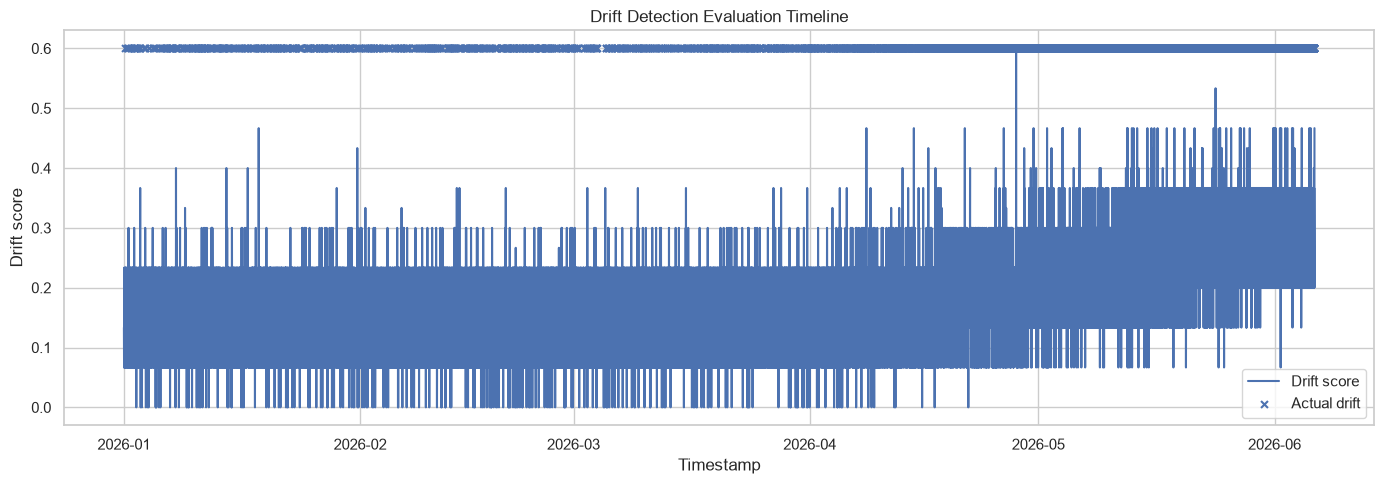

In [54]:
timestamp_candidates = [
    c for c in df.columns
    if normalize_name(c) in {
        "timestamp", "datetime", "date_time", "date", "recorded_at", "recorded_time"
    }
]

timestamp_col = timestamp_candidates[0] if timestamp_candidates else None

if timestamp_col:
    x = pd.to_datetime(df[timestamp_col], errors="coerce")
else:
    x = np.arange(len(df))

plt.figure(figsize=(14, 5))

if score_col:
    plt.plot(x, pd.to_numeric(df[score_col], errors="coerce"), label="Drift score")

if ground_truth_col and df["actual_drift"].astype(int).any():
    mask = df["actual_drift"].astype(int) == 1
    level = pd.to_numeric(df[score_col], errors="coerce").max() if score_col else 1
    plt.scatter(
        x[mask],
        np.full(mask.sum(), level),
        marker="x",
        s=25,
        label="Actual drift"
    )

plt.title("Drift Detection Evaluation Timeline")
plt.xlabel("Timestamp" if timestamp_col else "Production sequence")
plt.ylabel("Drift score")
plt.legend()
plt.tight_layout()
plt.show()

# 11 · Final Evaluation Summary

In [55]:
print("=" * 72)
print("PRODUCTION QUALITY DRIFT DETECTOR — EVALUATION")
print("=" * 72)

print(f"Ground truth: {ground_truth_col or 'NOT AVAILABLE'}")
print(f"Detector output: {detected_col or score_col or 'NOT AVAILABLE'}")

if ground_truth_col:
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"False Positive Rate: {fpr:.4f}")
    print(f"Detection delay: {detection_delay if not pd.isna(detection_delay) else 'Not detected'} observations")
    if not state_metrics.empty:
        print(f"Three-state accuracy: {state_metrics.loc[0, 'value']:.4f}")
else:
    print("Classification metrics require a ground-truth label.")

PRODUCTION QUALITY DRIFT DETECTOR — EVALUATION
Ground truth: actual_status
Detector output: detected_status
Accuracy: 0.7419
Precision: 0.9318
Recall: 0.2778
F1 Score: 0.4280
False Positive Rate: 0.0108
Detection delay: 41 observations
Three-state accuracy: 0.6803


# 12 · Export Evaluation Reports


In [56]:
data_dir = Path(DATA_PATH).parent

evaluation_summary = pd.DataFrame({
    "evaluation_type": ["ground_truth_status"],
    "ground_truth_available": [bool(ground_truth_col)],
    "ground_truth_column": [ground_truth_col or ""],
    "detector_output": [detected_col or score_col or ""],
    "accuracy": [accuracy],
    "precision": [precision],
    "recall": [recall],
    "f1": [f1],
    "false_positive_rate": [fpr],
    "detection_delay_observations": [detection_delay],
    "three_state_accuracy": [
        state_metrics.loc[0, "value"] if not state_metrics.empty else np.nan
    ]
})

summary_path = data_dir / "drift_evaluation_summary.csv"
metrics_path = data_dir / "drift_evaluation_metrics.csv"
variable_path = data_dir / "drift_variable_report.csv"

evaluation_summary.to_csv(summary_path, index=False)
metrics.to_csv(metrics_path, index=False)

if not variable_report.empty:
    variable_report.to_csv(variable_path, index=False)

print(f"Saved: {summary_path}")
print(f"Saved: {metrics_path}")
if not variable_report.empty:
    print(f"Saved: {variable_path}")

Saved: D:\Sarthak's Folder\Project\Hackathon\Data\drift_evaluation_summary.csv
Saved: D:\Sarthak's Folder\Project\Hackathon\Data\drift_evaluation_metrics.csv
Saved: D:\Sarthak's Folder\Project\Hackathon\Data\drift_variable_report.csv
